# 聖經知識助手 — QLoRA 微調全流程 Notebook

## 專案概述

使用 **google/gemma-3-4b-it** 模型，透過 **QLoRA** 技術對繁體中文和合本聖經進行微調，
建立能夠準確引用經文、解釋段落、回答聖經相關問題的知識助手。

## Pipeline 流程

```
聖經 Markdown (66卷) → 解析器 → 模板系統 → 樣本生成器 → HF Dataset
                                                          ↓
                        互動推論 ← 評估 ← 模型合併 ← QLoRA 訓練
```

## 目錄

| Section | 內容 | 說明 |
|---------|------|------|
| 1 | 環境設定 | 安裝依賴、匯入套件 |
| 2 | 設定 | 超參數、模型 ID、路徑 |
| 3 | 聖經解析器 | Markdown → 結構化資料 |
| 4 | 模板系統 | 6 種樣本類型的問答模板 |
| 5 | 樣本生成器 | 生成訓練用 QA 樣本 |
| 6 | 資料管線 | 驗證、去重、切分 |
| 7 | 資料探索 | 視覺化分佈與預覽 |
| 8 | QLoRA 訓練 | 載入模型、設定 LoRA、執行 SFT |
| 9 | 模型合併 | GPU 清理、合併 adapter |
| 10 | 多維度評估 | 經文召回、辨識、抗幻覺 |
| 11 | 互動推論 | 即時問答測試 |
| 12 | 清理與總結 | 釋放資源 |

## 硬體需求

- **訓練**: NVIDIA GPU，至少 16GB VRAM（推薦 24GB+）
- **推論/評估**: 至少 12GB VRAM
- **磁碟**: 約 30GB（模型 + 資料集 + checkpoints）

---
## Section 1: 環境設定

### 依賴套件

| 套件 | 用途 |
|------|------|
| `torch` | PyTorch 深度學習框架 |
| `transformers` | Hugging Face 模型載入與推論 |
| `trl` | SFT 訓練器 |
| `peft` | LoRA / QLoRA adapter |
| `bitsandbytes` | 4-bit 量化 |
| `datasets` | Hugging Face Dataset 格式 |
| `rouge_score` | ROUGE-L 評估指標 |
| `matplotlib` | 視覺化 |
| `tqdm` | 進度條 |

In [1]:
# ── 安裝依賴 ──
!pip install -q trl peft bitsandbytes rouge_score accelerate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 528.8/528.8 kB 9.4 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 31.2 MB/s eta 0:00:00:00:0100:01


In [2]:
# ── Hugging Face 登入 ──
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient

HF_TOKEN = UserSecretsClient().get_secret("HF_TOKEN")
login(token=HF_TOKEN)
print("Hugging Face login OK")

Hugging Face login OK


In [3]:
# ── 匯入所有套件 ──
from __future__ import annotations

import gc
import glob
import json
import os
import random
import re
import warnings
from collections import Counter
from dataclasses import dataclass

import matplotlib.pyplot as plt
import torch
from datasets import ClassLabel, Dataset, DatasetDict
from IPython.display import HTML, display
from tqdm.auto import tqdm

warnings.filterwarnings("ignore", category=FutureWarning)

print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
N_GPUS = torch.cuda.device_count()
print(f"GPU count: {N_GPUS}")
for i in range(N_GPUS):
    props = torch.cuda.get_device_properties(i)
    print(f"  [{i}] {props.name} — {props.total_memory / 1024**3:.1f} GB")

PyTorch: 2.9.0+cu126
CUDA available: True
GPU count: 1
  [0] Tesla P100-PCIE-16GB — 15.9 GB


---
## Section 2: 設定

包含模型 ID、系統提示詞、訓練超參數與路徑常數。

- `CONFIG` dict 取代 YAML 設定檔，所有超參數可直接編輯
- `SYSTEM_PROMPT` 為訓練時使用的系統提示詞（含 3 個變體增加多樣性）
- `report_to` 預設為 `"none"`，如需 Trackio 追蹤可改為 `"trackio"`

In [4]:
# ── 模型與路徑 ──
MODEL_ID = "google/gemma-3-4b-it"

DATA_DIR = "/kaggle/input/datasets/kenzx0521/bible-data/bible_data"
OUTPUT_DIR = "/kaggle/working/outputs"

# ── 系統提示詞 ──
SYSTEM_PROMPT = (
    "你是一位精通聖經的知識助手，熟悉繁體中文和合本聖經的所有內容。"
    "你能準確引用經文、解釋段落含義、提供上下文背景，並回答各種聖經相關問題。"
    "請根據聖經內容如實回答，若問題超出聖經範圍，請誠實說明。"
)

SYSTEM_PROMPT_VARIANTS = (
    SYSTEM_PROMPT,
    (
        "你是聖經知識助手，精通繁體中文和合本聖經全部66卷書的內容。"
        "你可以引用經文、說明段落意義、提供背景脈絡，並回答聖經相關的各類問題。"
        "回答請以聖經內容為依據，遇到超出範圍的問題請如實告知。"
    ),
    (
        "你是一位熟悉聖經的助手，對繁體中文和合本聖經的經文內容瞭若指掌。"
        "無論是查詢經文、理解段落含義或是探討聖經主題，你都能提供準確的回答。"
        "請依據聖經內容回應，若問題不在聖經範圍內，請誠實說明。"
    ),
    (
        "你是專業的聖經知識顧問，擅長繁體中文和合本聖經的經文查詢與解讀。"
        "你能精確引用經文、分析上下文脈絡，並解答各種與聖經相關的問題。"
        "請基於聖經原文內容作答，若問題超出聖經所涵蓋的範圍，請坦誠說明。"
    ),
)

# ── 訓練設定 ──
CONFIG = {
    "model": {"model_id": MODEL_ID},
    "quantization": {
        "load_in_4bit": True,
        "bnb_4bit_quant_type": "nf4",
        "bnb_4bit_use_double_quant": True,
        "bnb_4bit_compute_dtype": "bfloat16",
    },
    "lora": {
        "r": 16,
        "lora_alpha": 32,
        "lora_dropout": 0.1,
        "target_modules": "all-linear",
        "bias": "none",
        "task_type": "CAUSAL_LM",
    },
    "training": {
        "output_dir": "outputs/bible-assistant",
        "num_train_epochs": 2,
        "per_device_train_batch_size": 1,
        "gradient_accumulation_steps": 16,
        "learning_rate": 1e-4,
        "weight_decay": 0.01,
        "max_length": 1536,
        "packing": True,
        "gradient_checkpointing": True,
        "optim": "paged_adamw_8bit",
        "lr_scheduler_type": "cosine",
        "warmup_ratio": 0.05,
        "neftune_noise_alpha": 5,
        "logging_steps": 10,
        "save_strategy": "steps",
        "save_steps": 200,
        "save_total_limit": 5,
        "eval_strategy": "steps",
        "eval_steps": 200,
        "load_best_model_at_end": True,
        "metric_for_best_model": "eval_loss",
        "bf16": True,
        "report_to": "none",  # 改為 "trackio" 以啟用實驗追蹤
    },
    "dataset": {"test_size": 0.1, "seed": 42},
    # Trackio 設定（report_to="trackio" 時啟用）
    # "trackio": {
    #     "project": "bible-fine-tuning",
    #     "run_name": "qlora-google/gemma-3-4b-it",
    #     "space_id": "KenZx0521/fine-tuning_bible",
    # },
}

print(f"Model ID: {MODEL_ID}")
print(f"DATA_DIR: {DATA_DIR}")
print(f"OUTPUT_DIR: {OUTPUT_DIR}")

Model ID: google/gemma-3-4b-it
DATA_DIR: /kaggle/input/datasets/kenzx0521/bible-data/bible_data
OUTPUT_DIR: /kaggle/working/outputs


In [5]:
# ── SEED 與裝置 ──
SEED = CONFIG["dataset"]["seed"]
random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")


def gpu_mem():
    """顯示所有 GPU 記憶體使用狀況。"""
    if not torch.cuda.is_available():
        print("No GPU available")
        return
    for i in range(torch.cuda.device_count()):
        allocated = torch.cuda.memory_allocated(i) / 1024**3
        reserved = torch.cuda.memory_reserved(i) / 1024**3
        total = torch.cuda.get_device_properties(i).total_memory / 1024**3
        print(f"  GPU[{i}]: {allocated:.2f} / {total:.1f} GB (reserved: {reserved:.2f} GB)")


gpu_mem()

Device: cuda
  GPU[0]: 0.00 / 15.9 GB (reserved: 0.00 GB)


---
## Section 3: 聖經解析器

將 66 卷聖經 Markdown 檔案解析為結構化 Python 物件（`Book → Chapter → Section → Verse`）。

### Markdown 格式規則

```
# 創世記           ← H1: 書卷名稱
## 第 1 章          ← H2: 章號
### 上帝創造天地    ← H3: 段落標題
**1** 起初⋯⋯       ← 粗體數字: 節號 + 經文
```

### 邊界案例處理

| 案例 | 說明 | 處理方式 |
|------|------|----------|
| Broken H3 | `### 的君」。` | 偵測短文＋非句尾前行 → 合併至前一節 |
| 交叉引用 | `### （路3‧23-38）` | regex 過濾 |
| 音樂註記 | `（細拉）` | 過濾 |
| 多行詩歌 | 詩篇跨行經文 | 累積至下一節號 |
| 合併節號 | `**1-2**` | verse_number 以 str 儲存 |
| 註腳區塊 | `---` + `**註腳**` | 跳過後續行 |

In [6]:
# ── 資料結構（frozen dataclass）與 Regex ──

@dataclass(frozen=True)
class Verse:
    book: str
    chapter: int
    verse_number: str  # str 以支援 "1-2" 合併節
    text: str
    section_title: str


@dataclass(frozen=True)
class Section:
    title: str
    verses: tuple[Verse, ...]


@dataclass(frozen=True)
class Chapter:
    book: str
    number: int
    sections: tuple[Section, ...]


@dataclass(frozen=True)
class Book:
    name: str
    chapters: tuple[Chapter, ...]


# Regex 模式
_RE_H1 = re.compile(r"^# (.+)$")
_RE_H2 = re.compile(r"^## 第 (\d+) 章$")
_RE_H3 = re.compile(r"^### (.+)$")
_RE_VERSE = re.compile(r"^\*\*(\d+(?:-\d+)?)\*\*\s*(.*)$")
_RE_BROKEN_H3 = re.compile(r"^### .{1,6}[。！？，」）]$")
_RE_CROSS_REF = re.compile(r"^### （.+）$")
_RE_HORIZONTAL_RULE = re.compile(r"^-{3,}$")
_RE_FOOTNOTE_MARKER = re.compile(r"^\*\*註腳")
_RE_CHAPTER_VERSE_REF = re.compile(r"\d+‧\d+")


def _is_broken_h3(line: str, prev_line: str) -> bool:
    """偵測因行寬截斷產生的假 H3 標題。"""
    if not _RE_BROKEN_H3.match(line):
        return False
    stripped = prev_line.rstrip()
    if not stripped:
        return True
    return stripped[-1] not in "。！？」）；：\n"


def _is_cross_ref_or_annotation(line: str) -> bool:
    """偵測交叉引用與音樂註記。"""
    if _RE_CROSS_REF.match(line):
        return True
    if not line.startswith("### "):
        return False
    content = line[4:]
    if content.startswith("（") and _RE_CHAPTER_VERSE_REF.search(content):
        return True
    if content.startswith("*") and _RE_CHAPTER_VERSE_REF.search(content):
        return True
    return False

In [7]:
# ── 解析函式 ──

def parse_book(filepath: str) -> Book:
    """解析單卷聖經 Markdown 檔案為 Book dataclass。"""
    with open(filepath, "r", encoding="utf-8") as _f:
        text = _f.read()
    lines = text.split("\n")

    book_name = ""
    chapters: list[Chapter] = []
    current_chapter_num = 0
    current_section_title = ""
    current_sections: list[Section] = []
    current_verses: list[Verse] = []
    current_verse_num = ""
    current_verse_lines: list[str] = []
    prev_content_line = ""
    in_footnote = False

    def _flush_verse() -> None:
        nonlocal current_verse_num, current_verse_lines
        if current_verse_num and current_verse_lines:
            verse_text = "\n".join(current_verse_lines).strip()
            if verse_text:
                current_verses.append(
                    Verse(book=book_name, chapter=current_chapter_num,
                          verse_number=current_verse_num, text=verse_text,
                          section_title=current_section_title)
                )
        current_verse_num = ""
        current_verse_lines = []

    def _flush_section() -> None:
        nonlocal current_verses
        _flush_verse()
        if current_verses:
            current_sections.append(
                Section(title=current_section_title, verses=tuple(current_verses))
            )
            current_verses = []

    def _flush_chapter() -> None:
        nonlocal current_sections
        _flush_section()
        if current_sections and current_chapter_num > 0:
            chapters.append(
                Chapter(book=book_name, number=current_chapter_num,
                        sections=tuple(current_sections))
            )
            current_sections = []

    for line in lines:
        stripped = line.strip()
        if not stripped:
            continue
        if _RE_HORIZONTAL_RULE.match(stripped):
            _flush_verse()
            continue
        h1_match = _RE_H1.match(stripped)
        if h1_match:
            book_name = h1_match.group(1)
            continue
        h2_match = _RE_H2.match(stripped)
        if h2_match:
            _flush_chapter()
            current_chapter_num = int(h2_match.group(1))
            current_section_title = ""
            in_footnote = False
            continue
        h3_match = _RE_H3.match(stripped)
        if h3_match:
            if _is_cross_ref_or_annotation(stripped):
                continue
            if _is_broken_h3(stripped, prev_content_line):
                broken_text = h3_match.group(1)
                if current_verse_lines:
                    current_verse_lines.append(broken_text)
                elif current_verses:
                    last = current_verses[-1]
                    current_verses[-1] = Verse(
                        book=last.book, chapter=last.chapter,
                        verse_number=last.verse_number,
                        text=last.text + broken_text,
                        section_title=last.section_title,
                    )
                prev_content_line = broken_text
                continue
            _flush_section()
            current_section_title = h3_match.group(1)
            continue
        verse_match = _RE_VERSE.match(stripped)
        if verse_match:
            _flush_verse()
            current_verse_num = verse_match.group(1)
            verse_text = verse_match.group(2).strip()
            current_verse_lines = [verse_text] if verse_text else []
            prev_content_line = stripped
            continue
        if _RE_FOOTNOTE_MARKER.match(stripped):
            _flush_verse()
            in_footnote = True
            continue
        if in_footnote:
            continue
        if current_verse_num:
            current_verse_lines.append(stripped)
            prev_content_line = stripped
            continue
        prev_content_line = stripped

    _flush_chapter()
    return Book(name=book_name, chapters=tuple(chapters))


def parse_all_books(data_dir: str) -> list[Book]:
    """解析目錄下所有聖經 Markdown 檔案，依檔名排序。"""
    md_files = sorted(glob.glob(os.path.join(data_dir, "*.md")))
    if not md_files:
        raise FileNotFoundError(f"No markdown files found in {data_dir}")
    books = []
    for filepath in md_files:
        book = parse_book(filepath)
        if book.chapters:
            books.append(book)
    return books


def count_stats(books: list[Book]) -> dict[str, int]:
    """統計解析結果。"""
    return {
        "books": len(books),
        "chapters": sum(len(b.chapters) for b in books),
        "sections": sum(len(c.sections) for b in books for c in b.chapters),
        "verses": sum(
            len(s.verses) for b in books for c in b.chapters for s in c.sections
        ),
    }

---
## Section 4: 模板系統

定義 6 種樣本類型的問答模板、主題關鍵字、書卷分類與拒絕回應。

| 類型 | 名稱 | 說明 | 佔比 |
|------|------|------|------|
| A | 經文查詢 | 查詢特定經文內容 | ~30% |
| B | 段落摘要 | 概述段落內容 | ~13% |
| C | 主題經文 | 按主題搜尋經文 | ~6% |
| D | 上下文理解 | 提供經文前後文 | ~27% |
| E | 經文辨識 | 辨識經文出處 | ~17% |
| F | 拒絕回應 | 拒答超出範圍的問題 | ~5% |

In [8]:
# ── Type A: 經文查詢模板 ──

_VERSE_QUERY_TEMPLATES = (
    "{book}第{chapter}章第{verse}節的經文是什麼？",
    "請問{book}第{chapter}章第{verse}節說了什麼？",
    "請引用{book}第{chapter}章第{verse}節的經文。",
    "聖經{book}第{chapter}章{verse}節的內容為何？",
    "幫我查一下{book}第{chapter}章第{verse}節。",
    "{book}第{chapter}章第{verse}節寫了什麼？",
    "請告訴我{book}第{chapter}章第{verse}節的經文。",
    "我想知道{book}{chapter}章{verse}節的經文內容。",
    "{book}{chapter}章{verse}節是怎麼說的？",
    "{book}第{chapter}章第{verse}節記載了什麼？",
    "可以幫我看一下{book}第{chapter}章第{verse}節嗎？",
    "想請教{book}第{chapter}章第{verse}節的經文內容。",
    "我想查{book}{chapter}章{verse}節。",
    "{book}{chapter}:{verse}這段經文是什麼？",
    "請問聖經{book}第{chapter}章第{verse}節是怎麼記載的？",
    "{book}裏面{chapter}章{verse}節怎麼說的？",
    "查經文：{book}第{chapter}章第{verse}節。",
    "關於{book}第{chapter}章第{verse}節，那段經文怎麼寫的？",
    "請查閱{book}第{chapter}章第{verse}節的經文內容。",
    "可以告訴我{book}第{chapter}章第{verse}節的內容嗎？",
    "{book}第{chapter}章第{verse}節的經文內容為何？",
    "我想看{book}第{chapter}章第{verse}節的經文。",
    "麻煩幫我查{book}第{chapter}章第{verse}節。",
    "{book}第{chapter}章第{verse}節說了些什麼？",
    "請問{book}第{chapter}章{verse}節那段經文的內容？",
    "想知道{book}第{chapter}章第{verse}節的記載。",
    "{book}第{chapter}章第{verse}節有什麼經文？",
    "關於{book}{chapter}章{verse}節，聖經是怎麼說的？",
    "請幫我看{book}第{chapter}章第{verse}節的經文。",
    "想了解{book}第{chapter}章第{verse}節記載的內容。",
)

_VERSE_ANSWER_TEMPLATES = (
    "{book}第{chapter}章第{verse}節的經文是：\n\n「{text}」",
    "根據{book}第{chapter}章第{verse}節：\n\n「{text}」",
    "{book}第{chapter}章第{verse}節記載：\n\n「{text}」",
    "以下是{book}第{chapter}章第{verse}節的內容：\n\n「{text}」",
    "這段經文記載的是：\n\n「{text}」\n\n出自{book}第{chapter}章第{verse}節。",
    "好的，{book}第{chapter}章第{verse}節的經文如下：\n\n「{text}」",
    "{book}{chapter}章{verse}節寫道：\n\n「{text}」",
    "在{book}第{chapter}章第{verse}節中記載：\n\n「{text}」",
    "您所詢問的{book}第{chapter}章第{verse}節內容為：\n\n「{text}」",
    "這節經文是這樣的：\n\n「{text}」\n\n——{book}第{chapter}章第{verse}節",
    "查閱{book}第{chapter}章第{verse}節，經文內容為：\n\n「{text}」",
    "讓我為您引用{book}第{chapter}章第{verse}節：\n\n「{text}」",
    "{book}第{chapter}章第{verse}節是這樣說的：\n\n「{text}」",
    "關於{book}第{chapter}章第{verse}節，經文寫道：\n\n「{text}」",
)

_VERSE_ANSWER_EXTENDED_TEMPLATES = (
    "這節經文位於{book}第{chapter}章「{section_title}」段落中，第{verse}節記載：\n\n「{text}」",
    "{book}第{chapter}章第{verse}節，屬於「{section_title}」這一段的內容：\n\n「{text}」",
    "在{book}第{chapter}章的「{section_title}」段落裏，第{verse}節寫道：\n\n「{text}」",
    "好的，這段經文出自{book}第{chapter}章「{section_title}」段落：\n\n第{verse}節：「{text}」",
    "{book}第{chapter}章第{verse}節的經文如下：\n\n「{text}」\n\n這節位於「{section_title}」段落之中。",
    "根據{book}第{chapter}章第{verse}節：\n\n「{text}」\n\n此經文屬於「{section_title}」段落。",
)

# ── Type B: 段落摘要模板 ──

_SECTION_SUMMARY_TEMPLATES = (
    "請概述{book}第{chapter}章「{section}」這段的內容。",
    "{book}第{chapter}章中「{section}」這段經文在講什麼？",
    "請說明{book}第{chapter}章「{section}」段落的主要內容。",
    "請簡單介紹{book}第{chapter}章「{section}」的內容。",
    "聖經{book}第{chapter}章有一段叫「{section}」，這段在講什麼？",
    "{book}第{chapter}章「{section}」的重點是什麼？",
    "可以幫我整理{book}第{chapter}章「{section}」的內容嗎？",
    "「{section}」是{book}第{chapter}章的哪一段？這段在說什麼？",
    "{book}第{chapter}章中「{section}」這個段落包含哪些經文？",
    "請幫我歸納{book}第{chapter}章「{section}」段落的重點。",
)

_SECTION_ANSWER_TEMPLATES = (
    "{book}第{chapter}章「{section}」這段的內容如下：\n\n{verses_text}",
    "在{book}第{chapter}章中，「{section}」這段經文記載了以下內容：\n\n{verses_text}",
    "以下是{book}第{chapter}章「{section}」段落的經文：\n\n{verses_text}",
    "關於{book}第{chapter}章的「{section}」，其內容如下：\n\n{verses_text}",
    "好的，{book}第{chapter}章「{section}」段落的經文內容為：\n\n{verses_text}",
    "讓我為您查閱{book}第{chapter}章「{section}」的內容：\n\n{verses_text}",
    "{book}第{chapter}章中「{section}」這段記載如下：\n\n{verses_text}",
    "「{section}」出現在{book}第{chapter}章，經文內容為：\n\n{verses_text}",
    "您詢問的{book}第{chapter}章「{section}」段落包含以下經文：\n\n{verses_text}",
    "{book}第{chapter}章「{section}」的段落經文如下所示：\n\n{verses_text}",
)

In [9]:
# ── Type C: 主題經文模板 ──

_THEMATIC_TEMPLATES = (
    "聖經中有哪些關於「{topic}」的經文？",
    "請列出聖經中提到「{topic}」的經文。",
    "聖經裏關於「{topic}」的教導有哪些？",
    "「{topic}」這個主題在聖經中有哪些相關經文？",
    "我想了解聖經中關於「{topic}」的經文。",
    "可以幫我找聖經裏跟「{topic}」有關的經文嗎？",
    "聖經對於「{topic}」有什麼樣的教導？",
    "請問聖經哪些地方有提到「{topic}」？",
)

_THEMATIC_CATEGORY_TEMPLATES = (
    "{category}中有哪些關於「{topic}」的經文？",
    "請列出{category}中提到「{topic}」的經文。",
    "{category}裏關於「{topic}」的教導有哪些？",
    "「{topic}」這個主題在{category}中有哪些相關經文？",
    "我想看看{category}中跟「{topic}」相關的經文。",
    "可以幫我查{category}裏面關於「{topic}」的經文嗎？",
    "{category}對「{topic}」有哪些教導或記載？",
    "請問{category}中哪些經文跟「{topic}」有關？",
)

_THEMATIC_ANSWER_TEMPLATES = (
    "以下是一些關於「{topic}」的經文：\n\n{verse_lines}",
    "聖經中關於「{topic}」的經文如下：\n\n{verse_lines}",
    "關於「{topic}」，以下是相關的聖經經文：\n\n{verse_lines}",
    "讓我為您列出聖經中提到「{topic}」的經文：\n\n{verse_lines}",
    "以下經文與「{topic}」這個主題相關：\n\n{verse_lines}",
    "聖經裏提到「{topic}」的經文有：\n\n{verse_lines}",
    "好的，以下是與「{topic}」相關的聖經經文：\n\n{verse_lines}",
    "為您整理聖經中關於「{topic}」的經文如下：\n\n{verse_lines}",
)

_THEMATIC_CATEGORY_ANSWER_TEMPLATES = (
    "以下是{category}中關於「{topic}」的經文：\n\n{verse_lines}",
    "{category}中提到「{topic}」的經文如下：\n\n{verse_lines}",
    "關於「{topic}」，{category}中有以下記載：\n\n{verse_lines}",
    "在{category}裏，與「{topic}」相關的經文有：\n\n{verse_lines}",
    "好的，{category}中與「{topic}」相關的經文如下：\n\n{verse_lines}",
    "{category}裏提到「{topic}」的經文有這些：\n\n{verse_lines}",
    "讓我為您列出{category}中關於「{topic}」的經文：\n\n{verse_lines}",
    "為您查閱{category}中與「{topic}」相關的記載：\n\n{verse_lines}",
)

_TESTAMENT_CATEGORIES: dict[str, tuple[str, ...]] = {
    "舊約": ("律法書", "歷史書", "詩歌智慧書", "大先知書", "小先知書"),
    "新約": ("福音書", "教會歷史", "保羅書信", "一般書信", "啟示文學"),
}

_THEMATIC_TESTAMENT_TEMPLATES = (
    "{testament}中有哪些關於「{topic}」的經文？",
    "請列出{testament}中提到「{topic}」的經文。",
    "{testament}裏關於「{topic}」的教導有哪些？",
    "「{topic}」這個主題在{testament}中有哪些相關經文？",
    "我想了解{testament}中關於「{topic}」的經文。",
    "可以幫我找{testament}裏跟「{topic}」有關的經文嗎？",
    "{testament}對於「{topic}」有什麼樣的教導？",
    "請問{testament}哪些地方有提到「{topic}」？",
)

_THEMATIC_TESTAMENT_ANSWER_TEMPLATES = (
    "以下是{testament}中關於「{topic}」的經文：\n\n{verse_lines}",
    "{testament}中提到「{topic}」的經文如下：\n\n{verse_lines}",
    "關於「{topic}」，{testament}中有以下記載：\n\n{verse_lines}",
    "在{testament}裏，與「{topic}」相關的經文有：\n\n{verse_lines}",
)

# ── 主題關鍵字（58 個主題，含 include/exclude 規則）──

TOPIC_KEYWORDS: dict[str, dict] = {
    "創造": {"include": ["創造", "造物", "起初"], "exclude": ["建造", "打造", "製造", "造訪"]},
    "救贖": {"include": ["救贖", "拯救", "救恩", "得救"], "exclude": []},
    "信心": {"include": ["信心", "相信", "信靠"], "exclude": ["書信", "信差", "送信"]},
    "愛": {"include": ["慈愛", "仁愛", "愛人", "愛心", "相愛"], "exclude": []},
    "立約": {"include": ["立約", "盟約", "新約", "守約"], "exclude": []},
    "先知預言": {"include": ["預言", "先知"], "exclude": []},
    "禱告": {"include": ["禱告", "祈禱", "祈求", "呼求"], "exclude": []},
    "智慧": {"include": ["智慧", "聰明"], "exclude": []},
    "公義": {"include": ["公義", "正義", "公正"], "exclude": []},
    "盼望": {"include": ["盼望", "指望", "仰望"], "exclude": []},
    "恩典": {"include": ["恩典", "恩惠"], "exclude": []},
    "平安": {"include": ["平安"], "exclude": []},
    "審判": {"include": ["審判", "刑罰", "懲罰"], "exclude": []},
    "罪與赦免": {"include": ["罪孽", "過犯", "犯罪", "赦免"], "exclude": []},
    "悔改": {"include": ["悔改", "回轉", "歸向"], "exclude": []},
    "聖靈": {"include": ["聖靈"], "exclude": []},
    "永生": {"include": ["永生", "永遠的生命"], "exclude": []},
    "敬拜讚美": {"include": ["敬拜", "頌讚", "讚美", "稱頌"], "exclude": []},
    "順服": {"include": ["順服", "順從", "遵行", "遵守"], "exclude": []},
    "苦難": {"include": ["苦難", "患難", "受苦"], "exclude": []},
    "復活": {"include": ["復活", "從死裏"], "exclude": []},
    "天國": {"include": ["天國", "天上的國", "上帝的國", "神的國"], "exclude": []},
    "十字架": {"include": ["十字架", "釘十字架"], "exclude": []},
    "洗禮": {"include": ["洗禮", "受洗", "施洗"], "exclude": []},
    "聖殿": {"include": ["聖殿", "殿裏", "殿中"], "exclude": []},
    "天使": {"include": ["天使"], "exclude": ["高天使"]},
    "喜樂": {"include": ["喜樂", "歡喜", "喜悅"], "exclude": []},
    "饒恕": {"include": ["饒恕", "寬恕", "原諒"], "exclude": []},
    "謙卑": {"include": ["謙卑", "謙虛", "謙遜"], "exclude": []},
    "試探": {"include": ["試探", "誘惑", "引誘"], "exclude": []},
    "光明": {"include": ["光明", "光照", "發光"], "exclude": ["刀劍", "槍矛", "銅"]},
    "安息": {"include": ["安息", "歇息"], "exclude": ["安息日"]},
    "應許": {"include": ["應許", "應驗"], "exclude": []},
    "聖潔": {"include": ["聖潔", "潔淨"], "exclude": []},
    "忍耐": {"include": ["忍耐", "忍受"], "exclude": []},
    "感恩": {"include": ["感恩", "感謝", "稱謝"], "exclude": []},
    "僕人": {"include": ["僕人", "奴僕", "服事"], "exclude": []},
    "牧者": {"include": ["牧者", "牧人", "牧羊"], "exclude": []},
    "葡萄園": {"include": ["葡萄園", "葡萄樹"], "exclude": []},
    "生命": {"include": ["生命", "活水", "生命樹"], "exclude": []},
    "死亡": {"include": ["死亡", "死人", "陰間"], "exclude": ["安息"]},
    "耶路撒冷": {"include": ["耶路撒冷", "錫安"], "exclude": []},
    "出埃及": {"include": ["出埃及", "法老"], "exclude": []},
    "獻祭": {"include": ["獻祭", "祭物", "燔祭"], "exclude": []},
    "律法": {"include": ["律法", "誡命", "典章"], "exclude": []},
    "醫治": {"include": ["醫治", "醫好", "痊癒"], "exclude": []},
    "神蹟": {"include": ["神蹟", "奇事", "異能"], "exclude": []},
    "合一": {"include": ["合一", "同心", "合而為一"], "exclude": []},
    "祝福": {"include": ["祝福", "賜福", "蒙福"], "exclude": []},
    "揀選": {"include": ["揀選", "選召", "選民"], "exclude": []},
    "榮耀": {"include": ["榮耀", "榮光"], "exclude": []},
    "安慰": {"include": ["安慰", "慰藉"], "exclude": []},
    "爭戰": {"include": ["爭戰", "打仗", "戰爭"], "exclude": []},
    "曠野": {"include": ["曠野", "沙漠", "荒野"], "exclude": []},
    "安息日": {"include": ["安息日"], "exclude": []},
    "逾越節": {"include": ["逾越節", "逾越"], "exclude": []},
    "比喻": {"include": ["比喻", "比方"], "exclude": []},
    "見證": {"include": ["見證", "作證"], "exclude": []},
    "異象": {"include": ["異象", "異夢"], "exclude": []},
    "仇敵": {"include": ["仇敵", "敵人", "對敵"], "exclude": []},
    "豐收": {"include": ["豐收", "收割", "莊稼"], "exclude": []},
    "使命": {"include": ["使命", "差遣", "差派"], "exclude": []},
    "天父": {"include": ["天父", "父神"], "exclude": []},
    "羔羊": {"include": ["羔羊", "羊羔"], "exclude": []},
    "誠實": {"include": ["誠實", "真誠", "誠信"], "exclude": []},
    "勇氣": {"include": ["勇敢", "壯膽", "剛強"], "exclude": []},
    "貧窮": {"include": ["貧窮", "窮人", "貧乏"], "exclude": []},
    "寶血": {"include": ["寶血", "血約", "流血"], "exclude": []},
    "教會": {"include": ["教會", "會眾"], "exclude": []},
    "福音": {"include": ["福音", "好消息"], "exclude": []},
    "呼召": {"include": ["呼召", "蒙召"], "exclude": []},
    "權柄": {"include": ["權柄", "權能", "權勢"], "exclude": []},
    "憐憫": {"include": ["憐憫", "憐恤", "施恩"], "exclude": []},
    "產業": {"include": ["產業", "基業", "地業"], "exclude": []},
    "約櫃": {"include": ["約櫃", "法櫃"], "exclude": []},
    "恩賜": {"include": ["恩賜", "屬靈的恩賜"], "exclude": []},
    "末世": {"include": ["末世", "末後", "末日"], "exclude": []},
    "受膏": {"include": ["受膏", "膏抹", "彌賽亞"], "exclude": []},
}

# ── 書卷分類 ──

_BOOK_CATEGORIES: dict[str, tuple[str, ...]] = {
    "律法書": ("創世記", "出埃及記", "利未記", "民數記", "申命記"),
    "歷史書": (
        "約書亞記", "士師記", "路得記", "撒母耳記上", "撒母耳記下",
        "列王紀上", "列王紀下", "歷代志上", "歷代志下", "以斯拉記",
        "尼希米記", "以斯帖記",
    ),
    "詩歌智慧書": ("約伯記", "詩篇", "箴言", "傳道書", "雅歌"),
    "大先知書": ("以賽亞書", "耶利米書", "耶利米哀歌", "以西結書", "但以理書"),
    "小先知書": (
        "何西阿書", "約珥書", "阿摩司書", "俄巴底亞書", "約拿書",
        "彌迦書", "那鴻書", "哈巴谷書", "西番雅書", "哈該書",
        "撒迦利亞書", "瑪拉基書",
    ),
    "福音書": ("馬太福音", "馬可福音", "路加福音", "約翰福音"),
    "教會歷史": ("使徒行傳",),
    "保羅書信": (
        "羅馬書", "哥林多前書", "哥林多後書", "加拉太書", "以弗所書",
        "腓立比書", "歌羅西書", "帖撒羅尼迦前書", "帖撒羅尼迦後書",
        "提摩太前書", "提摩太後書", "提多書", "腓利門書",
    ),
    "一般書信": (
        "希伯來書", "雅各書", "彼得前書", "彼得後書",
        "約翰一書", "約翰二書", "約翰三書", "猶大書",
    ),
    "啟示文學": ("啟示錄",),
}

_BOOK_TO_CATEGORY: dict[str, str] = {}
for _cat, _book_names in _BOOK_CATEGORIES.items():
    for _bn in _book_names:
        _BOOK_TO_CATEGORY[_bn] = _cat

In [10]:
# ── Type D: 上下文理解模板 ──

_CONTEXT_TEMPLATES = (
    "{book}第{chapter}章第{verse}節的上下文是什麼？",
    "請提供{book}第{chapter}章第{verse}節的前後文背景。",
    "{book}第{chapter}章第{verse}節出現在什麼樣的段落背景中？",
    "請解釋{book}第{chapter}章第{verse}節的上下文脈絡。",
    "幫我看看{book}第{chapter}章第{verse}節的前後文。",
    "{book}{chapter}章{verse}節出現在什麼語境之中？",
    "請問{book}第{chapter}章第{verse}節前後在說些什麼？",
    "{book}第{chapter}章第{verse}節附近的經文是什麼？",
    "我想了解{book}第{chapter}章第{verse}節的上下文。",
    "請幫我查一下{book}第{chapter}章第{verse}節的段落背景。",
    "請描述{book}第{chapter}章第{verse}節的段落背景與上下文。",
    "請問{book}第{chapter}章第{verse}節這段經文的來龍去脈。",
    "{book}第{chapter}章第{verse}節附近有哪些相關的經文？",
    "可以幫我看看{book}第{chapter}章第{verse}節所在段落的完整內容嗎？",
    "想知道{book}第{chapter}章第{verse}節前後的經文在講什麼。",
    "{book}第{chapter}章第{verse}節這節經文周圍的內容是什麼？",
    "請問{book}第{chapter}章第{verse}節前後各有什麼經文？",
    "幫我理解{book}第{chapter}章第{verse}節的上下文脈絡。",
    "{book}{chapter}章{verse}節的段落主題和前後文是什麼？",
    "請告訴我{book}第{chapter}章第{verse}節前一節和後一節的內容。",
    "{book}第{chapter}章第{verse}節的上下文環境是怎樣的？",
    "我想看{book}第{chapter}章第{verse}節周邊的經文。",
    "請問{book}第{chapter}章第{verse}節是在討論什麼主題時提到的？",
    "關於{book}第{chapter}章第{verse}節，它的上文和下文分別是什麼？",
    "{book}第{chapter}章第{verse}節在整段經文中的位置和前後文是什麼？",
)

_CONTEXT_ANSWER_TEMPLATES = (
    "{book}第{chapter}章第{verse}節的上下文如下：\n\n{context_text}{section_info}",
    "以下是{book}第{chapter}章第{verse}節的前後文：\n\n{context_text}{section_info}",
    "讓我為您查閱{book}第{chapter}章第{verse}節的上下文脈絡：\n\n{context_text}{section_info}",
    "{book}{chapter}章{verse}節出現在以下段落之中：\n\n{context_text}{section_info}",
    "關於{book}第{chapter}章第{verse}節的段落背景：\n\n{context_text}{section_info}",
    "好的，以下是{book}第{chapter}章第{verse}節附近的經文內容：\n\n{context_text}{section_info}",
)

# ── Type E: 經文辨識模板 ──

_IDENTIFICATION_TEMPLATES = (
    "「{text}」這句經文出自聖經哪裏？",
    "「{text}」這段話是聖經哪一卷哪一章哪一節？",
    "請問「{text}」出自聖經的什麼地方？",
    "「{text}」是哪卷書的經文？",
    "「{text}」這句話在聖經哪裏？",
    "請幫我找一下「{text}」這段經文的出處。",
    "「{text}」是聖經裏面哪個地方的？",
    "有一段經文說「{text}」，這是出自哪裏的？",
    "請查閱「{text}」這段經文出自聖經何處。",
    "「{text}」這段話的聖經出處為何？",
    "請問「{text}」記載在聖經的哪一卷書？",
    "「{text}」這句經文的出處與章節為何？",
    "我記得聖經裏有一段「{text}」，請問出自哪裏？",
    "「{text}」好像是聖經的經文，可以告訴我出處嗎？",
    "想確認一下「{text}」是不是聖經的內容，出自哪裏？",
    "聽過一句「{text}」，請問這是聖經哪一段？",
    "幫我查經文「{text}」的出處。",
    "可以幫我確認「{text}」是出自聖經哪裏嗎？",
    "想請教「{text}」這段經文是來自哪卷書？",
    "麻煩查一下「{text}」出自聖經第幾卷第幾章。",
)

_IDENTIFICATION_ANSWER_TEMPLATES = (
    "這句經文出自{book}第{chapter}章第{verse}節。",
    "這段話記載在{book}第{chapter}章第{verse}節。",
    "您引用的經文出自{book}第{chapter}章第{verse}節。",
    "這是{book}第{chapter}章第{verse}節的經文。",
    "經查閱，這句話出自{book}第{chapter}章第{verse}節。",
    "這段經文的出處是{book}第{chapter}章第{verse}節。",
)

_IDENTIFICATION_ANSWER_WITH_SECTION_TEMPLATES = (
    "這句經文出自{book}第{chapter}章第{verse}節，位於「{section_title}」段落中。",
    "這段話記載在{book}第{chapter}章第{verse}節，屬於「{section_title}」段落。",
    "您引用的經文出自{book}第{chapter}章第{verse}節，出現在「{section_title}」這一段中。",
    "經查閱，這句話出自{book}第{chapter}章第{verse}節，段落主題為「{section_title}」。",
    "這段經文來自{book}第{chapter}章第{verse}節，位於「{section_title}」的段落之中。",
    "這是{book}第{chapter}章第{verse}節的經文，收錄在「{section_title}」段落裏。",
)

_IDENTIFICATION_ANSWER_ENRICHED_NO_SECTION = (
    "您引用的「{text}」這段經文出自{book}第{chapter}章第{verse}節。",
    "「{text}」記載在{book}第{chapter}章第{verse}節中。",
    "這段話「{text}」的出處是{book}第{chapter}章第{verse}節。",
    "經查閱，「{text}」出自{book}第{chapter}章第{verse}節。",
)

_IDENTIFICATION_ANSWER_ENRICHED_WITH_SECTION = (
    "「{text}」記載在{book}第{chapter}章第{verse}節中。這節經文位於「{section_title}」段落。",
    "經查閱，「{text}」出自{book}第{chapter}章第{verse}節，屬於「{section_title}」段落的內容。",
    "您所引用的「{text}」來自{book}第{chapter}章第{verse}節，收錄在「{section_title}」段落之中。",
    "沒錯，「{text}」的確出自{book}第{chapter}章第{verse}節，位於「{section_title}」段落。",
)

In [11]:
# ── Type F: 拒絕回應模板與資料 ──

_FAKE_BOOKS = (
    "保羅書", "彼拉多書", "馬利亞福音", "多馬福音", "巴拿巴書",
    "以諾書", "所羅門智訓", "便西拉智訓", "瑪加伯書",
    "亞當書", "夏娃書", "亞伯拉罕書", "摩西秘密書", "約瑟福音",
    "拿撒勒福音", "十二使徒福音", "抹大拉福音", "腓力福音",
    "真理福音", "埃及人福音",
    "雅各福音", "西門書", "彼得福音", "安得烈書", "猶大福音",
    "尼哥底母福音", "拉撒路書", "巴錄書", "以斯拉二書", "赫馬牧人書",
    "約瑟禱詞", "亞伯拉罕啟示錄", "以利亞書", "摩西升天記",
    "所羅門詩篇", "以賽亞殉道記", "彼得啟示錄", "多馬行傳",
    "巴拿巴福音", "耶利米書信", "瑪拿西禱詞", "以斯拉四書",
)

_REFUSAL_NONEXISTENT_BOOK = (
    "聖經正典中沒有「{book}」這卷書。聖經共有66卷書，{book}並不包含在內。",
    "「{book}」不是聖經正典中的書卷。如果您想查詢聖經經文，請提供正確的書卷名稱。",
    "很抱歉，「{book}」並非聖經正典的一部分。聖經正典共66卷，不包含此書。",
    "「{book}」不在聖經66卷正典之中。請確認您要查詢的書卷名稱是否正確。",
    "聖經中沒有「{book}」這卷書。您可能想查詢的是其他書卷，請提供正確的名稱。",
    "抱歉，{book}不是聖經正典中的書卷。如需幫助，請告訴我您想查的經文出處。",
)

_REFUSAL_OUT_OF_RANGE = (
    "{book}只有{max_ch}章，沒有第{ch}章。請確認章節範圍。",
    "很抱歉，{book}共有{max_ch}章，第{ch}章超出範圍。",
    "{book}總共只有{max_ch}章，並沒有第{ch}章。請重新確認。",
    "您查詢的第{ch}章超出了{book}的範圍。{book}共有{max_ch}章。",
    "抱歉，{book}只有{max_ch}章，沒有第{ch}章的內容。請確認章節編號。",
    "{book}最多只到第{max_ch}章，第{ch}章不存在。請提供正確的章數。",
)

_REFUSAL_OUT_OF_RANGE_VERSE = (
    "{book}第{ch}章只有{max_v}節，沒有第{v}節。請確認節數範圍。",
    "很抱歉，{book}第{ch}章共有{max_v}節，第{v}節超出範圍。",
    "您查詢的{book}第{ch}章第{v}節超出範圍，該章只有{max_v}節。",
    "{book}第{ch}章最多到第{max_v}節，沒有第{v}節的內容。請確認節數。",
    "抱歉，{book}第{ch}章共{max_v}節，第{v}節不存在。請重新確認。",
    "{book}第{ch}章只有{max_v}節，您查詢的第{v}節超出了範圍。",
)

_REFUSAL_NON_BIBLE = (
    "這個問題超出了聖經的範圍。我是聖經知識助手，專門回答與聖經相關的問題。",
    "很抱歉，這不是聖經的內容。我的專長是回答聖經相關問題，如果您有聖經方面的疑問，歡迎提問。",
    "抱歉，這個問題不在聖經的範疇之內。如果您有聖經相關的問題，我很樂意為您解答。",
    "這個問題與聖經無關。我是專門回答聖經問題的助手，歡迎您提出聖經相關的疑問。",
    "很抱歉，我無法回答這個問題，因為它不屬於聖經的內容。請提出與聖經相關的問題。",
    "這超出了我的專業範圍。作為聖經知識助手，我專注於聖經經文和教導的相關問題。",
    "這個問題涉及其他宗教的經典，不屬於聖經的範圍。我只能為您解答與聖經相關的問題。",
    "很抱歉，這是科學領域的問題，超出了聖經知識的範疇。歡迎您向我提出聖經方面的疑問。",
    "這個問題屬於文學作品的範疇，並非聖經的內容。如果您想了解聖經的記載，我很樂意幫忙。",
    "這是一個歷史學的問題，不在聖經討論的範圍之內。我專門回答聖經經文與教導的問題。",
    "抱歉，這個問題屬於哲學領域，超出了聖經的範圍。如有聖經相關的問題，歡迎提問。",
    "這是關於語言學的問題，不屬於聖經的內容。我的專長是聖經經文查詢與教導解說。",
    "這個問題涉及科技領域，超出了我作為聖經知識助手的範圍。請提出與聖經相關的問題。",
    "很抱歉，這是飲食生活方面的問題，不在聖經的範疇之內。歡迎您詢問聖經相關的內容。",
    "這個問題不屬於聖經知識的範圍。我是聖經助手，專注於聖經經文、書卷和教導方面的問題。",
)

_REFUSAL_NON_BIBLE_GENERIC: tuple[str, ...] = (
    "這個問題超出了聖經的範圍。我是聖經知識助手，專門回答與聖經相關的問題。",
    "很抱歉，這不是聖經的內容。我的專長是回答聖經相關問題，如果您有聖經方面的疑問，歡迎提問。",
    "抱歉，這個問題不在聖經的範疇之內。如果您有聖經相關的問題，我很樂意為您解答。",
    "這個問題與聖經無關。我是專門回答聖經問題的助手，歡迎您提出聖經相關的疑問。",
    "很抱歉，我無法回答這個問題，因為它不屬於聖經的內容。請提出與聖經相關的問題。",
    "這超出了我的專業範圍。作為聖經知識助手，我專注於聖經經文和教導的相關問題。",
    "這個問題不屬於聖經知識的範圍。我是聖經助手，專注於聖經經文、書卷和教導方面的問題。",
)

_REFUSAL_NON_BIBLE_BY_CATEGORY: dict[str, tuple[str, ...]] = {
    "宗教": (
        "這個問題涉及其他宗教的經典，不屬於聖經的範圍。我只能為您解答與聖經相關的問題。",
        "很抱歉，這是關於其他宗教傳統的問題，不在聖經知識的範疇內。歡迎您詢問聖經相關的內容。",
    ),
    "科學": (
        "很抱歉，這是科學領域的問題，超出了聖經知識的範疇。歡迎您向我提出聖經方面的疑問。",
        "這個問題屬於自然科學的範圍，不在聖經討論的領域之內。我專門回答聖經經文與教導的問題。",
    ),
    "文學": (
        "這個問題屬於文學作品的範疇，並非聖經的內容。如果您想了解聖經的記載，我很樂意幫忙。",
        "很抱歉，這是關於文學藝術的問題，超出了聖經知識助手的範圍。歡迎您提出聖經相關的問題。",
    ),
    "歷史": (
        "這是一個歷史學的問題，不在聖經討論的範圍之內。我專門回答聖經經文與教導的問題。",
        "很抱歉，這個問題涉及世界歷史，超出了聖經知識的範疇。如有聖經相關問題，歡迎提問。",
    ),
    "哲學": (
        "抱歉，這個問題屬於哲學領域，超出了聖經的範圍。如有聖經相關的問題，歡迎提問。",
        "這是一個哲學思想的問題，不在聖經知識助手的服務範圍內。歡迎您詢問聖經經文與教導。",
    ),
    "語言": (
        "這是關於語言學的問題，不屬於聖經的內容。我的專長是聖經經文查詢與教導解說。",
        "很抱歉，這個問題涉及語言學習，超出了聖經知識的範疇。歡迎您提出聖經方面的問題。",
    ),
    "科技": (
        "這個問題涉及科技領域，超出了我作為聖經知識助手的範圍。請提出與聖經相關的問題。",
        "很抱歉，這是科技方面的問題，不在聖經知識的範疇之內。如有聖經問題，歡迎詢問。",
    ),
    "飲食": (
        "很抱歉，這是飲食生活方面的問題，不在聖經的範疇之內。歡迎您詢問聖經相關的內容。",
        "這個問題涉及飲食健康，超出了聖經知識助手的範圍。歡迎您提出聖經相關的問題。",
    ),
}

_MISSPELLED_BOOKS: dict[str, str] = {
    "創世紀": "創世記", "啟示書": "啟示錄", "出埃及": "出埃及記",
    "利未紀": "利未記", "撒母耳上": "撒母耳記上", "列王記上": "列王紀上",
    "歷代記上": "歷代志上", "約伯紀": "約伯記", "以賽亞": "以賽亞書",
    "耶利米": "耶利米書", "但以理": "但以理書", "馬太福": "馬太福音",
    "希伯來": "希伯來書", "雅歌書": "雅歌", "箴言書": "箴言",
    "傳道紀": "傳道書", "彼得書": "彼得前書", "哥林多書": "哥林多前書",
    "帖撒羅尼加前書": "帖撒羅尼迦前書", "腓力比書": "腓立比書",
}

_REFUSAL_MISSPELLED_BOOK = (
    "聖經中沒有「{book}」這個名稱，您可能想查的是「{correct_book}」。請使用正確的書卷名稱查詢。",
    "「{book}」似乎是書卷名稱的誤寫，正確名稱應為「{correct_book}」。請用正確名稱重新查詢。",
    "您提到的「{book}」可能有誤，聖經中對應的書卷是「{correct_book}」。請確認後再查詢。",
    "抱歉，「{book}」不是正確的書卷名稱。您是否想查詢「{correct_book}」？",
    "聖經正典中的正確名稱是「{correct_book}」，而非「{book}」。請使用正確的名稱查詢。",
    "「{book}」這個名稱有誤，正確的聖經書卷名稱為「{correct_book}」。",
)

_MAX_SECTION_ANSWER_CHARS = 1500

_FAKE_QUERY_TEMPLATES = (
    "{book}第{ch}章第1節的經文是什麼？",
    "請引用{book}第{ch}章第{v}節的經文。",
    "請問{book}第{ch}章第{v}節說了什麼？",
    "{book}第{ch}章第{v}節記載了什麼？",
    "幫我查一下{book}第{ch}章第{v}節。",
    "我想知道{book}第{ch}章第{v}節的內容。",
    "{book}第{ch}章第{v}節寫了什麼？",
    "可以告訴我{book}第{ch}章第{v}節嗎？",
    "請查閱{book}第{ch}章第{v}節的經文。",
    "{book}第{ch}章第{v}節的經文內容為何？",
    "想請教{book}第{ch}章第{v}節的經文。",
    "{book}{ch}章{v}節是怎麼說的？",
    "查經文：{book}第{ch}章第{v}節。",
    "關於{book}第{ch}章第{v}節，經文怎麼寫的？",
    "請告訴我{book}第{ch}章第{v}節說了些什麼。",
)

In [12]:
# ── 非聖經問題（按類別分組，共 204 題）──

_NON_BIBLE_QUESTIONS_BY_CATEGORY: dict[str, tuple[str, ...]] = {
    "宗教": (
        "佛經金剛經的第一段內容是什麼？", "可蘭經第一章說了什麼？",
        "道德經的開頭是什麼？", "吠陀經的內容是什麼？",
        "摩門經第一章說了什麼？", "請問薄伽梵歌的主題是什麼？",
        "心經的全文是什麼？", "莊子逍遙遊的大意是什麼？",
        "塔木德中關於智慧的教導有哪些？", "法華經的主旨是什麼？",
        "般若波羅蜜多心經的核心教義是什麼？", "六祖壇經的禪學思想是什麼？",
        "阿含經中關於四聖諦的教導？", "道德經第一章的「道可道非常道」是什麼意思？",
        "太上感應篇的內容是什麼？", "關聖帝君桃園明聖經的意義？",
        "古蘭經中關於齋月的教導？", "印度教梵天創世的故事是什麼？",
        "奧義書中關於梵我合一的思想？", "請問佛教的八正道是什麼？",
        "印度教的種姓制度是如何形成的？", "請介紹日本神道教的基本信仰。",
        "道教煉丹術的歷史背景是什麼？", "蘇菲派神祕主義的核心教義是什麼？",
        "錫克教的五K戒律是什麼？", "祆教（拜火教）的基本教義是什麼？",
        "耆那教的非暴力原則是什麼？", "巴哈伊信仰的核心原則是什麼？",
        "請問藏傳佛教的特色是什麼？", "禪宗的核心修行方法是什麼？",
        "伊斯蘭教的五功是什麼？", "猶太教的安息日有什麼規定？",
        "印度教的四大目標是什麼？", "請問什麼是正念冥想？",
    ),
    "科學": (
        "請問量子力學的基本原理是什麼？", "請解釋黑洞的物理特性。",
        "請說明DNA雙螺旋結構的發現過程。", "牛頓三大運動定律是什麼？",
        "請解釋相對論。", "請問光合作用的化學反應式是什麼？",
        "人類基因組計畫的主要成果是什麼？", "請解釋暗物質和暗能量的差異。",
        "地球的年齡是如何測定的？", "請說明板塊構造學說。",
        "請問光速是多少？", "太陽系有幾顆行星？",
        "達爾文的進化論核心概念是什麼？", "孟德爾遺傳定律是什麼？",
        "請問什麼是熱力學第二定律？", "薛丁格方程式描述什麼？",
        "請問DNA的結構是什麼？", "什麼是幹細胞技術？",
        "人工光合作用是什麼概念？", "石墨烯的特性和應用是什麼？",
        "請解釋潮汐的形成原因。", "極光是如何形成的？",
        "月球上有水嗎？", "畢達哥拉斯定理是什麼？",
        "圓周率的歷史發現過程是什麼？", "什麼是歐幾里得幾何？",
        "集合論的基本概念是什麼？", "複數的定義和用途是什麼？",
        "什麼是黃金比例？", "請說明微積分的基本概念。",
        "費馬大定理是什麼？", "哥德巴赫猜想是什麼？",
        "請問什麼是黎曼假設？",
    ),
    "文學": (
        "紅樓夢的主題是什麼？", "三國演義中諸葛亮的形象如何？",
        "水滸傳中有哪些英雄好漢？", "西遊記的孫悟空有什麼特殊能力？",
        "莎士比亞的哈姆雷特主要在講什麼？", "請推薦一部好看的電影。",
        "莫札特的主要音樂成就是什麼？", "貝多芬的命運交響曲表達了什麼？",
        "爵士樂的起源和發展歷史？", "請介紹印象派繪畫的特色。",
        "畢卡索的立體主義是什麼？", "巴赫的音樂風格有什麼特色？",
        "蕭邦的鋼琴作品有哪些代表作？", "搖滾樂的起源和發展是什麼？",
        "京劇的四大行當是什麼？", "交響樂團的編制是什麼？",
        "嘻哈音樂的文化背景是什麼？",
    ),
    "歷史": (
        "拿破崙的歷史影響是什麼？", "法國大革命的主要原因有哪些？",
        "工業革命對社會的影響是什麼？", "羅馬帝國衰亡的原因是什麼？",
        "文藝復興的主要特徵是什麼？", "二戰的主要起因是什麼？",
        "冷戰期間的主要事件有哪些？", "鄭和下西洋的歷史意義是什麼？",
        "秦始皇統一中國的影響是什麼？", "甲骨文的發現對歷史研究有何意義？",
        "金字塔是如何建造的？", "羅馬競技場的歷史背景是什麼？",
    ),
    "哲學": (
        "論語學而篇的內容是什麼？", "孟子的核心思想是什麼？",
        "儒家五常是什麼？", "墨子的兼愛思想是什麼？",
        "韓非子的法治思想是什麼？", "荀子的性惡論是什麼？",
        "朱熹理學的核心概念是什麼？", "儒家三綱五常的具體內容是什麼？",
        "請問馬克思主義的核心觀點是什麼？", "尼采的超人哲學是什麼意思？",
        "康德的純粹理性批判在說什麼？", "存在主義的基本概念是什麼？",
        "柏拉圖的理型論是什麼？", "蘇格拉底的哲學方法是什麼？",
        "老子的無為思想是什麼意思？", "笛卡爾的「我思故我在」是什麼意思？",
        "功利主義的核心概念是什麼？", "海德格爾的存在哲學主要在說什麼？",
        "維根斯坦的語言哲學核心觀點是什麼？", "太極哲學中的陰陽概念是什麼？",
        "請說明社會契約論。",
    ),
    "語言": (
        "請幫我翻譯這段英文。", "請問如何學好英文？",
        "請推薦學習日文的方法。", "德語和英語有什麼相似之處？",
        "西班牙語在全球的使用情況如何？", "阿拉伯語書法有哪些風格？",
        "拉丁語對現代語言的影響是什麼？",
    ),
    "科技": (
        "幫我寫一段Python程式碼。", "人工智慧的未來發展趨勢如何？",
        "請說明區塊鏈的運作原理。", "人工智慧會取代人類的工作嗎？",
        "虛擬實境技術的最新發展是什麼？", "請解釋機器學習和深度學習的區別。",
        "自動駕駛汽車的安全性如何？", "太空探索的未來方向是什麼？",
        "請問什麼是5G技術？", "元宇宙的概念是什麼？",
        "量子電腦和傳統電腦有什麼不同？", "請解釋雲端運算的基本概念。",
        "什麼是物聯網？", "什麼是比特幣？",
        "電動車的優缺點是什麼？", "太陽能發電的原理是什麼？",
    ),
    "飲食": (
        "請問如何煮義大利麵？", "請推薦一些健康的飲食習慣。",
        "請問如何製作日本壽司？", "法國料理的五大醬汁是什麼？",
        "請介紹中國八大菜系。", "泰國料理的特色香料有哪些？",
        "義大利披薩的發源歷史是什麼？", "地中海飲食的特色是什麼？",
        "請問什麼是生酮飲食？", "請介紹中醫的五行學說。",
        "阿育吠陀醫學的基本原理是什麼？",
    ),
    "通用": (
        "請問今天天氣如何？", "請問台灣的首都在哪裏？",
        "2024年的美國總統是誰？", "股票市場今天的走勢如何？",
        "全球暖化的主要原因是什麼？", "請問如何投資股票基金？",
        "請問瑜伽的起源和哲學基礎是什麼？", "太極拳的健康益處有哪些？",
        "冥想對身心健康有什麼影響？", "奧運會的起源是什麼？",
        "世界盃足球賽幾年舉辦一次？", "NBA的三分線距離是多少？",
        "棒球比賽一局有幾個出局數？", "馬拉松比賽的起源故事是什麼？",
        "網球四大滿貫分別是哪些？", "高爾夫球的標準桿數是多少？",
        "羽毛球場的標準尺寸是多少？", "巴黎聖母院的建築風格是什麼？",
        "萬里長城的總長度是多少？", "哥德式建築的特色是什麼？",
        "請介紹日本傳統建築的特色。", "請問世界上最長的河流是哪條？",
        "喜馬拉雅山的最高峰是什麼？", "亞馬遜雨林面積有多大？",
        "北極和南極的差異是什麼？", "馬里亞納海溝有多深？",
        "撒哈拉沙漠的面積是多少？", "如何計算BMI指數？",
        "請介紹常見的有氧運動。", "馬拉松的標準距離是多少？",
        "請問什麼是可持續發展？", "碳中和的概念是什麼？",
        "請說明溫室效應的原理。", "什麼是循環經濟？",
        "海洋污染的主要來源有哪些？", "請問什麼是GDP？",
        "通貨膨脹的原因是什麼？", "請解釋供需法則。",
        "請說明複利的概念。", "民主制度的核心價值是什麼？",
        "聯合國的主要功能有哪些？", "請問什麼是人權宣言？",
        "三權分立的原則是什麼？", "請問如何學好數學？",
        "什麼是STEM教育？", "蒙特梭利教育法的特色是什麼？",
        "芬蘭教育為什麼被認為成功？", "請問如何提升閱讀理解能力？",
        "請問什麼是碳足跡？",
    ),
}

_NON_BIBLE_QUESTIONS: tuple[str, ...] = tuple(
    q for qs in _NON_BIBLE_QUESTIONS_BY_CATEGORY.values() for q in qs
)

# ── 邊界問題（聖經相關但需審慎回答）──

_BOUNDARY_QUESTIONS = (
    ("聖經中有提到恐龍嗎？", "聖經中沒有直接提到「恐龍」這個詞。不過約伯記第40-41章描述了「河馬」（巨獸）和「鱷魚」（力威亞探），有些學者認為這些描述可能與大型古生物有關，但這並非定論。"),
    ("聖經中有提到外星人嗎？", "聖經中沒有直接提到外星人。聖經的焦點是上帝與人類的關係，關於地球以外是否有生命，聖經並未明確論述。"),
    ("亞當和夏娃是真實的歷史人物嗎？", "聖經創世記第2-3章記載了亞當和夏娃的故事。關於其歷史性，不同的聖經學者有不同的理解。作為聖經知識助手，我可以為您提供聖經經文的內容，但關於歷史性的判斷，建議您參考不同的神學觀點。"),
    ("聖經支持進化論嗎？", "聖經本身並未討論進化論。創世記第1章記載上帝在六日內創造天地萬物。關於聖經創造記載與科學理論的關係，不同的神學傳統有不同的理解。我可以為您提供相關的聖經經文。"),
    ("聖經如何看待氣候變遷？", "聖經並未直接討論現代意義的氣候變遷。不過聖經中有關於人類管理大地的教導，如創世記第1章28節提到管理地上的一切。關於環境議題的具體立場，需要結合神學和科學的討論。"),
    ("聖經對人工智慧有什麼看法？", "聖經寫成的年代遠早於人工智慧的概念，因此並未直接論及此議題。聖經中有關於智慧、創造力和人類獨特性的教導，但將這些應用到現代科技議題需要謹慎的神學詮釋。"),
    ("地球到底有幾歲？聖經怎麼說？", "聖經本身沒有明確記載地球的年齡。有些學者根據聖經族譜推算約六千年，但也有學者認為創世記的「日」不一定指24小時。這涉及不同的聖經詮釋傳統，我可以為您提供相關的經文內容。"),
    ("三位一體是聖經的教導嗎？", "「三位一體」這個詞本身沒有出現在聖經中，但許多基督徒認為聖經中有多處經文支持這個概念，例如馬太福音28章19節提到「奉父、子、聖靈的名」。這是一個需要深入神學討論的主題。"),
    ("聖經中的地獄是什麼樣子？", "聖經中有多處提到審判和懲罰的概念，使用了不同的詞彙如「陰間」、「火湖」等。不同的經文和神學傳統對這些描述有不同的理解。如果您想了解具體的經文，我可以為您查閱。"),
    ("聖經如何看待女性的地位？", "聖經中關於女性的記載很多元。創世記記載男女都按上帝的形象被造，箴言31章讚揚才德的婦人，新約中也有許多女性扮演重要角色。不同的經文反映不同的歷史文化背景，需要整體理解。"),
    ("聖經是否支持奴隸制度？", "聖經寫成於奴隸制度普遍存在的時代，某些經文反映了當時的社會制度。但聖經中也有呼籲平等的教導，如加拉太書3章28節說「不分...為奴的、自主的」。這個議題需要考慮歷史背景和整體聖經信息。"),
    ("聖經怎麼看同性議題？", "這是一個在不同基督教傳統中有不同理解的議題。聖經中有數處經文被引用在這個討論中，如利未記18章、羅馬書1章等。不同的學者對這些經文有不同的詮釋。作為聖經知識助手，我可以提供相關經文的內容。"),
    ("基督徒應該支持政教分離嗎？", "聖經中有一些與此相關的經文，如耶穌在馬太福音22章21節說「凱撒的物當歸給凱撒；上帝的物當歸給上帝」。但對於政教關係的具體看法，不同的神學傳統有不同的理解。我可以為您查閱相關經文。"),
    ("聖經如何看待動物權利？", "聖經中有關於善待動物的教導，如箴言12章10節提到「義人顧惜他牲畜的命」。創世記也記載人類受託管理萬物。但「動物權利」是現代概念，聖經的教導需要在其歷史語境中理解。"),
    ("聖經是否支持戰爭？", "聖經中既有記載戰爭的經文（如約書亞記），也有追求和平的教導（如以賽亞書2章4節「鑄劍為犁」）。耶穌在登山寶訓中教導「使人和睦的人有福了」。這個議題在不同的神學傳統中有不同的理解。"),
    ("挪亞方舟是真實存在的嗎？", "聖經創世記第6-9章記載了挪亞方舟的故事。至今有人聲稱在土耳其亞拉臘山發現方舟遺跡，但考古學上尚無定論。作為聖經知識助手，我可以提供相關經文的內容。"),
    ("該隱的妻子是誰？", "聖經創世記第4章17節提到該隱有妻子，但沒有具體說明她的來歷。創世記第5章4節提到亞當生兒養女，傳統解釋認為該隱娶了自己的姊妹。這是一個常見的聖經問題。"),
    ("聖經中的巴別塔是怎麼回事？", "聖經創世記第11章1-9節記載了巴別塔的故事。人們企圖建造通天的塔，上帝變亂他們的口音使他們分散各地。這段經文常被理解為解釋語言多樣性的起源故事。"),
    ("耶穌有兄弟姊妹嗎？", "聖經中有提到耶穌的兄弟，如馬太福音13章55-56節。但不同的基督教傳統對「兄弟」一詞有不同的理解——有些認為是親兄弟，有些認為是堂兄弟或表兄弟。我可以為您提供相關經文。"),
    ("聖經中的數字有特殊含義嗎？", "聖經中確實有些數字被認為具有象徵意義，如7代表完全、12代表上帝的子民、40代表試煉期等。但這些解釋需要在具體的經文語境中理解，不宜過度推論。"),
    ("聖經的預言都應驗了嗎？", "基督教傳統認為許多舊約預言在新約中得到應驗，例如彌賽亞的預言。但對於哪些預言已經應驗、哪些尚未應驗，不同的神學傳統有不同的理解。我可以提供具體的預言經文供您參考。"),
    ("聖經怎麼看待金錢和財富？", "聖經中有多處關於金錢的教導。提摩太前書6章10節說「貪財是萬惡之根」，但聖經也記載了約伯、亞伯拉罕等富有的義人。重點在於對財富的態度而非財富本身。"),
    ("基督徒可以吃豬肉嗎？", "舊約利未記11章禁止食用豬肉，但新約使徒行傳10章記載彼得的異象中，上帝宣告所有食物潔淨。大多數基督教傳統認為這些飲食律法在新約時代已不再適用。"),
    ("聖經怎麼看待死刑？", "舊約律法中有死刑的規定（如出埃及記21章），但耶穌在約翰福音8章中說「你們中間誰是沒有罪的，誰就可以先拿石頭打她」。不同的基督教傳統對死刑有不同的立場。"),
    ("聖經是怎麼寫成的？", "聖經由約40位作者在約1500年間寫成，包括66卷書。基督教傳統認為聖經是上帝默示的，但對於「默示」的具體方式，不同的神學傳統有不同的理解。我可以提供相關的經文參考。"),
    ("聖經中有矛盾嗎？", "聖經中有些看似不一致的記載，例如四福音書對同一事件的不同描述。不同的學者有不同的處理方式——有些認為這反映不同的視角，有些認為需要更深入的文本分析。具體問題可以具體討論。"),
    ("聖經如何看待離婚？", "聖經中有幾處關於離婚的教導。馬太福音19章記載耶穌論離婚，申命記24章也有相關律法。不同的基督教傳統對離婚的立場不盡相同。我可以為您查閱具體的經文內容。"),
    ("末日審判什麼時候來？", "聖經中有關於末日的教導，如馬太福音24章、啟示錄等，但耶穌在馬太福音24章36節明確說「那日子，那時辰，沒有人知道」。因此任何試圖預測具體日期的嘗試都不符合聖經教導。"),
    ("聖經如何看待其他宗教？", "聖經強調敬拜獨一真神（出埃及記20章3節），耶穌也說「我就是道路、真理、生命」（約翰福音14章6節）。但對於如何理解和回應其他宗教，不同的基督教傳統有不同的神學立場。"),
    ("天堂是什麼樣子？", "聖經中有多處描述天堂的經文，如啟示錄21-22章描述新天新地。但這些描述多使用象徵性語言，如黃金街道、生命樹等。不同的神學傳統對這些描述有不同程度的字面或象徵解讀。"),
)

---
## Section 5: 樣本生成器

根據解析後的聖經結構與模板系統，生成 6 種類型的訓練樣本。

### 生成策略

| 類型 | 策略 |
|------|------|
| A | 漸進式降採樣（8%/18%/30%）+ 書卷最低保證（30 筆） |
| B | 過濾空標題段落 + 長段落截斷（>1500 字元取前 8 節） |
| C | 主題關鍵字匹配 + 類別/整體/新舊約 多面向生成 |
| D | 18% 章節取樣 + 前後文組裝 |
| E | 25 字元門檻 + snippet 去重 + 4 層回答豐富化 |
| F | 假書/超範圍/非聖經/邊界/錯字 五類拒絕樣本 |

In [13]:
# ── Sample dataclass 與輔助函式 ──

_MIN_SAMPLES_PER_BOOK = 30


@dataclass(frozen=True)
class Sample:
    """單一訓練樣本。"""
    sample_type: str  # A, B, C, D, E, F
    messages: tuple[dict[str, str], ...]


def _make_messages(
    question: str, answer: str, system_prompt: str = SYSTEM_PROMPT
) -> tuple[dict[str, str], ...]:
    """建立 TRL SFT 格式的 messages tuple。"""
    return (
        {"role": "system", "content": system_prompt},
        {"role": "user", "content": question},
        {"role": "assistant", "content": answer},
    )


def _collect_all_verses(books: list[Book]) -> list[Verse]:
    """展平所有書卷的經文。"""
    return [
        v for book in books for chapter in book.chapters
        for section in chapter.sections for v in section.verses
    ]


def _build_chapter_verse_list(chapter: Chapter) -> list[Verse]:
    """取得章內所有經文（按順序）。"""
    return [v for s in chapter.sections for v in s.verses]


def _normalize_inner_quotes(text: str) -> str:
    """將內層「」轉為『』，避免模板包裹後產生巢狀引號。"""
    return text.replace("「", "『").replace("」", "』")


def _fix_quote_pairing(text: str) -> str:
    """修復不成對的引號（截斷後可能產生）。"""
    for open_q, close_q in (("「", "」"), ("『", "』")):
        n_open = text.count(open_q)
        n_close = text.count(close_q)
        if n_open > n_close:
            text = text + close_q * (n_open - n_close)
        elif n_close > n_open:
            text = open_q * (n_close - n_open) + text
    return text


def _prepare_verse_text(text: str) -> str:
    """正規化內層引號並修復配對。"""
    return _fix_quote_pairing(_normalize_inner_quotes(text))


def _make_snippet(text: str) -> str:
    """從經文中擷取有意義的片段用於辨識。"""
    snippet = text
    if len(snippet) > 50:
        for sep in ("。", "；", "，"):
            pos = snippet.find(sep, 20)
            if pos != -1:
                snippet = snippet[:pos + 1]
                break
        else:
            snippet = snippet[:50] + "……"
    return snippet

In [14]:
# ── Type A, B, C 生成器 ──

def generate_type_a(books: list[Book], rng: random.Random) -> list[Sample]:
    """經文查詢樣本（漸進式降採樣 + 書卷最低保證）。"""
    eligible_per_book: dict[str, list[Verse]] = {}
    for book in books:
        book_verses = [
            v for ch in book.chapters for sec in ch.sections
            for v in sec.verses if len(v.text) >= 15
        ]
        if book_verses:
            eligible_per_book[book.name] = book_verses

    sampled_per_book: dict[str, list[Verse]] = {}
    for book_name, verses in eligible_per_book.items():
        sampled = []
        for verse in verses:
            text_len = len(verse.text)
            if text_len <= 25 and rng.random() > 0.08:
                continue
            elif 25 < text_len <= 40 and rng.random() > 0.18:
                continue
            elif text_len > 40 and rng.random() > 0.30:
                continue
            sampled.append(verse)
        sampled_per_book[book_name] = sampled

    for book_name, sampled in sampled_per_book.items():
        if len(sampled) < _MIN_SAMPLES_PER_BOOK:
            eligible = eligible_per_book[book_name]
            if len(eligible) <= _MIN_SAMPLES_PER_BOOK:
                sampled_per_book[book_name] = list(eligible)
            else:
                already = set(id(v) for v in sampled)
                remaining = [v for v in eligible if id(v) not in already]
                need = _MIN_SAMPLES_PER_BOOK - len(sampled)
                extra = rng.sample(remaining, min(need, len(remaining)))
                sampled_per_book[book_name] = sampled + extra

    samples = []
    for verses in sampled_per_book.values():
        for verse in verses:
            sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
            template = rng.choice(_VERSE_QUERY_TEMPLATES)
            question = template.format(
                book=verse.book, chapter=verse.chapter, verse=verse.verse_number,
            )
            use_extended = verse.section_title and rng.random() < 0.60
            if use_extended:
                answer_template = rng.choice(_VERSE_ANSWER_EXTENDED_TEMPLATES)
                answer = answer_template.format(
                    book=verse.book, chapter=verse.chapter,
                    verse=verse.verse_number, text=_prepare_verse_text(verse.text),
                    section_title=verse.section_title,
                )
            else:
                answer_template = rng.choice(_VERSE_ANSWER_TEMPLATES)
                answer = answer_template.format(
                    book=verse.book, chapter=verse.chapter,
                    verse=verse.verse_number, text=_prepare_verse_text(verse.text),
                )
            samples.append(Sample(sample_type="A", messages=_make_messages(question, answer, sys_prompt)))
    return samples


def generate_type_b(books: list[Book], rng: random.Random) -> list[Sample]:
    """段落摘要樣本（過濾空標題 + 長段落截斷）。"""
    samples = []
    for book in books:
        for chapter in book.chapters:
            for section in chapter.sections:
                if not section.verses or not section.title:
                    continue
                sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
                template = rng.choice(_SECTION_SUMMARY_TEMPLATES)
                question = template.format(
                    book=book.name, chapter=chapter.number, section=section.title,
                )
                full_text = "\n".join(
                    f"第{v.verse_number}節：{_fix_quote_pairing(v.text)}" for v in section.verses
                )
                if len(full_text) <= _MAX_SECTION_ANSWER_CHARS:
                    verses_text = full_text
                else:
                    shown = section.verses[:8]
                    verses_text = "\n".join(
                        f"第{v.verse_number}節：{_fix_quote_pairing(v.text)}" for v in shown
                    )
                    verses_text += (
                        f"\n\n（本段共{len(section.verses)}節經文，"
                        f"以上列出前{len(shown)}節）"
                    )
                answer_template = rng.choice(_SECTION_ANSWER_TEMPLATES)
                answer = answer_template.format(
                    book=book.name, chapter=chapter.number,
                    section=section.title, verses_text=verses_text,
                )
                samples.append(Sample(sample_type="B", messages=_make_messages(question, answer, sys_prompt)))
    return samples


def _match_topic(verse_text: str, topic_config: dict) -> bool:
    """檢查經文是否匹配主題（含排除規則）。"""
    includes = topic_config["include"]
    excludes = topic_config["exclude"]
    if not any(kw in verse_text for kw in includes):
        return False
    if excludes and any(kw in verse_text for kw in excludes):
        return False
    return True


def _build_topic_index(books: list[Book]) -> dict[str, list[Verse]]:
    """建立主題 → 經文索引。"""
    index: dict[str, list[Verse]] = {topic: [] for topic in TOPIC_KEYWORDS}
    for verse in _collect_all_verses(books):
        for topic, config in TOPIC_KEYWORDS.items():
            if _match_topic(verse.text, config):
                index[topic].append(verse)
    return index


def _get_testament_for_category(category: str) -> str | None:
    for testament, categories in _TESTAMENT_CATEGORIES.items():
        if category in categories:
            return testament
    return None


def generate_type_c(books: list[Book], rng: random.Random, verses_per_sample: int = 6) -> list[Sample]:
    """主題經文樣本（多面向生成）。"""
    index = _build_topic_index(books)
    samples = []
    for topic, all_verses in index.items():
        if len(all_verses) < 3:
            continue
        used_verse_ids: set[int] = set()
        category_verses: dict[str, list[Verse]] = {}
        for v in all_verses:
            cat = _BOOK_TO_CATEGORY.get(v.book, "其他")
            category_verses.setdefault(cat, []).append(v)

        for cat, cat_verses in category_verses.items():
            if len(cat_verses) < 1:
                continue
            available = [v for v in cat_verses if id(v) not in used_verse_ids]
            if not available:
                continue
            sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
            n_show = min(len(available), verses_per_sample)
            selected = rng.sample(available, n_show)
            used_verse_ids.update(id(v) for v in selected)
            template = rng.choice(_THEMATIC_CATEGORY_TEMPLATES)
            question = template.format(category=cat, topic=topic)
            verse_lines_text = "\n".join(
                f"- {v.book}第{v.chapter}章第{v.verse_number}節：「{_prepare_verse_text(v.text)}」"
                for v in selected
            )
            answer_template = rng.choice(_THEMATIC_CATEGORY_ANSWER_TEMPLATES)
            answer = answer_template.format(category=cat, topic=topic, verse_lines=verse_lines_text)
            samples.append(Sample(sample_type="C", messages=_make_messages(question, answer, sys_prompt)))

        for overall_idx in range(3):
            if overall_idx == 1 and len(all_verses) < verses_per_sample * 2:
                break
            elif overall_idx == 2 and len(all_verses) < verses_per_sample * 3:
                break
            available = [v for v in all_verses if id(v) not in used_verse_ids]
            if len(available) < 1:
                break
            sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
            n_show = min(len(available), verses_per_sample)
            selected = rng.sample(available, n_show)
            used_verse_ids.update(id(v) for v in selected)
            template = rng.choice(_THEMATIC_TEMPLATES)
            question = template.format(topic=topic)
            verse_lines_text = "\n".join(
                f"- {v.book}第{v.chapter}章第{v.verse_number}節：「{_prepare_verse_text(v.text)}」"
                for v in selected
            )
            answer_template = rng.choice(_THEMATIC_ANSWER_TEMPLATES)
            answer = answer_template.format(topic=topic, verse_lines=verse_lines_text)
            samples.append(Sample(sample_type="C", messages=_make_messages(question, answer, sys_prompt)))

        testament_verses: dict[str, list[Verse]] = {}
        for v in all_verses:
            cat = _BOOK_TO_CATEGORY.get(v.book)
            if cat:
                testament = _get_testament_for_category(cat)
                if testament:
                    testament_verses.setdefault(testament, []).append(v)
        for testament, t_verses in testament_verses.items():
            available = [v for v in t_verses if id(v) not in used_verse_ids]
            if len(available) < 2:
                continue
            sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
            n_show = min(len(available), verses_per_sample)
            selected = rng.sample(available, n_show)
            used_verse_ids.update(id(v) for v in selected)
            template = rng.choice(_THEMATIC_TESTAMENT_TEMPLATES)
            question = template.format(testament=testament, topic=topic)
            verse_lines_text = "\n".join(
                f"- {v.book}第{v.chapter}章第{v.verse_number}節：「{_prepare_verse_text(v.text)}」"
                for v in selected
            )
            answer_template = rng.choice(_THEMATIC_TESTAMENT_ANSWER_TEMPLATES)
            answer = answer_template.format(testament=testament, topic=topic, verse_lines=verse_lines_text)
            samples.append(Sample(sample_type="C", messages=_make_messages(question, answer, sys_prompt)))
    return samples

In [15]:
# ── Type D, E, F 生成器 ──

def generate_type_d(books: list[Book], rng: random.Random, sample_ratio: float = 0.18) -> list[Sample]:
    """上下文理解樣本。"""
    samples = []
    for book in books:
        for chapter in book.chapters:
            all_verses = _build_chapter_verse_list(chapter)
            if len(all_verses) < 3:
                continue
            n_samples = max(1, int(len(all_verses) * sample_ratio))
            selected_indices = rng.sample(range(len(all_verses)), n_samples)
            for idx in selected_indices:
                verse = all_verses[idx]
                sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
                template = rng.choice(_CONTEXT_TEMPLATES)
                question = template.format(book=verse.book, chapter=verse.chapter, verse=verse.verse_number)
                parts = []
                if idx > 0:
                    prev = all_verses[idx - 1]
                    parts.append(f"前文（第{prev.verse_number}節）：「{_prepare_verse_text(prev.text)}」")
                parts.append(f"本節（第{verse.verse_number}節）：「{_prepare_verse_text(verse.text)}」")
                if idx < len(all_verses) - 1:
                    nxt = all_verses[idx + 1]
                    parts.append(f"後文（第{nxt.verse_number}節）：「{_prepare_verse_text(nxt.text)}」")
                context_text = "\n".join(parts)
                section_info = (
                    f"\n\n這節經文位於「{verse.section_title}」段落中。"
                    if verse.section_title else ""
                )
                answer_template = rng.choice(_CONTEXT_ANSWER_TEMPLATES)
                answer = answer_template.format(
                    book=verse.book, chapter=verse.chapter, verse=verse.verse_number,
                    context_text=context_text, section_info=section_info,
                )
                samples.append(Sample(sample_type="D", messages=_make_messages(question, answer, sys_prompt)))
    return samples


def generate_type_e(books: list[Book], rng: random.Random, sample_ratio: float = 0.15) -> list[Sample]:
    """經文辨識樣本（snippet 去重 + 4 層回答豐富化）。"""
    all_verses = _collect_all_verses(books)
    eligible = [v for v in all_verses if len(v.text) >= 25]
    n_target = max(1, int(len(eligible) * sample_ratio))
    n_candidates = min(int(n_target * 1.15), len(eligible))
    candidates = rng.sample(eligible, n_candidates)
    seen_snippets: set[str] = set()
    selected: list[Verse] = []
    for verse in candidates:
        snippet = _make_snippet(verse.text)
        if snippet in seen_snippets:
            continue
        seen_snippets.add(snippet)
        selected.append(verse)
        if len(selected) >= n_target:
            break

    samples = []
    for verse in selected:
        sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
        text_snippet = _make_snippet(verse.text)
        if len(text_snippet) < 20:
            text_snippet = verse.text
        text_snippet = _fix_quote_pairing(text_snippet)
        text_snippet = _normalize_inner_quotes(text_snippet)
        template = rng.choice(_IDENTIFICATION_TEMPLATES)
        question = template.format(text=text_snippet)
        roll = rng.random()
        if verse.section_title and roll < 0.30:
            answer_template = rng.choice(_IDENTIFICATION_ANSWER_ENRICHED_WITH_SECTION)
            answer = answer_template.format(
                text=text_snippet, book=verse.book, chapter=verse.chapter,
                verse=verse.verse_number, section_title=verse.section_title,
            )
        elif roll < 0.55:
            answer_template = rng.choice(_IDENTIFICATION_ANSWER_ENRICHED_NO_SECTION)
            answer = answer_template.format(
                text=text_snippet, book=verse.book, chapter=verse.chapter, verse=verse.verse_number,
            )
        elif verse.section_title and roll < 0.80:
            answer_template = rng.choice(_IDENTIFICATION_ANSWER_WITH_SECTION_TEMPLATES)
            answer = answer_template.format(
                book=verse.book, chapter=verse.chapter,
                verse=verse.verse_number, section_title=verse.section_title,
            )
        else:
            answer_template = rng.choice(_IDENTIFICATION_ANSWER_TEMPLATES)
            answer = answer_template.format(book=verse.book, chapter=verse.chapter, verse=verse.verse_number)
        samples.append(Sample(sample_type="E", messages=_make_messages(question, answer, sys_prompt)))
    return samples


def generate_type_f(books: list[Book], rng: random.Random) -> list[Sample]:
    """拒絕樣本（5 類）。"""
    samples = []
    max_chapters: dict[str, int] = {}
    for book in books:
        if book.chapters:
            max_chapters[book.name] = max(c.number for c in book.chapters)

    # F1: 假書
    for fake_book in _FAKE_BOOKS:
        for ch in rng.sample(range(1, 11), 5):
            v = rng.randint(1, 20)
            sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
            template = rng.choice(_FAKE_QUERY_TEMPLATES)
            question = template.format(book=fake_book, ch=ch, v=v)
            answer = rng.choice(_REFUSAL_NONEXISTENT_BOOK).format(book=fake_book)
            samples.append(Sample(sample_type="F", messages=_make_messages(question, answer, sys_prompt)))

    # F2: 超出章數範圍
    real_books = list(max_chapters.keys())
    for _ in range(280):
        book_name = rng.choice(real_books)
        max_ch = max_chapters[book_name]
        fake_ch = max_ch + rng.randint(1, 50)
        v = rng.randint(1, 30)
        sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
        template = rng.choice(_FAKE_QUERY_TEMPLATES)
        question = template.format(book=book_name, ch=fake_ch, v=v)
        answer = rng.choice(_REFUSAL_OUT_OF_RANGE).format(book=book_name, max_ch=max_ch, ch=fake_ch)
        samples.append(Sample(sample_type="F", messages=_make_messages(question, answer, sys_prompt)))

    # F2b: 超出節數範圍
    max_verses_per_chapter: dict[str, dict[int, int]] = {}
    for book in books:
        book_verses: dict[int, int] = {}
        for chapter in book.chapters:
            verse_count = sum(len(s.verses) for s in chapter.sections)
            if verse_count > 0:
                book_verses[chapter.number] = verse_count
        if book_verses:
            max_verses_per_chapter[book.name] = book_verses
    for _ in range(220):
        book_name = rng.choice(list(max_verses_per_chapter.keys()))
        ch_map = max_verses_per_chapter[book_name]
        ch = rng.choice(list(ch_map.keys()))
        max_v = ch_map[ch]
        fake_v = max_v + rng.randint(1, 30)
        sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
        template = rng.choice(_FAKE_QUERY_TEMPLATES)
        question = template.format(book=book_name, ch=ch, v=fake_v)
        answer = rng.choice(_REFUSAL_OUT_OF_RANGE_VERSE).format(book=book_name, ch=ch, max_v=max_v, v=fake_v)
        samples.append(Sample(sample_type="F", messages=_make_messages(question, answer, sys_prompt)))

    # F3: 非聖經問題（類別感知拒絕）
    for category, questions in _NON_BIBLE_QUESTIONS_BY_CATEGORY.items():
        cat_templates = _REFUSAL_NON_BIBLE_BY_CATEGORY.get(category)
        for question in questions:
            sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
            if cat_templates and rng.random() < 0.60:
                answer = rng.choice(cat_templates)
            else:
                answer = rng.choice(_REFUSAL_NON_BIBLE_GENERIC)
            samples.append(Sample(sample_type="F", messages=_make_messages(question, answer, sys_prompt)))

    # F4: 邊界問題
    for question, answer in _BOUNDARY_QUESTIONS:
        sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
        samples.append(Sample(sample_type="F", messages=_make_messages(question, answer, sys_prompt)))

    # F5: 書名錯字
    for wrong_name, correct_name in _MISSPELLED_BOOKS.items():
        for _ in range(5):
            ch = rng.randint(1, 10)
            v = rng.randint(1, 20)
            sys_prompt = rng.choice(SYSTEM_PROMPT_VARIANTS)
            template = rng.choice(_FAKE_QUERY_TEMPLATES)
            question = template.format(book=wrong_name, ch=ch, v=v)
            answer = rng.choice(_REFUSAL_MISSPELLED_BOOK).format(book=wrong_name, correct_book=correct_name)
            samples.append(Sample(sample_type="F", messages=_make_messages(question, answer, sys_prompt)))
    return samples

In [16]:
# ── 總指揮 ──

def generate_all_samples(books: list[Book], seed: int = 42) -> list[Sample]:
    """生成所有訓練樣本（6 種類型）。"""
    rng = random.Random(seed)
    samples: list[Sample] = []
    samples.extend(generate_type_a(books, rng))
    samples.extend(generate_type_b(books, rng))
    samples.extend(generate_type_c(books, rng))
    samples.extend(generate_type_d(books, rng))
    samples.extend(generate_type_e(books, rng))
    samples.extend(generate_type_f(books, rng))
    return samples

---
## Section 6: 資料管線

將樣本轉換為 Hugging Face DatasetDict，包含：

1. **問題去重** — 移除重複的 user 問題
2. **長度過濾** — 過濾超過 1400 字元的樣本
3. **分層切分** — 按 sample_type 分層的 train/test split（90%/10%）
4. **儲存 checkpoint** — 可從此處重新載入

In [17]:
# ── 驗證與轉換函式 ──

_MAX_TOTAL_CHARS = 1400


def _estimate_too_long(sample: Sample, max_chars: int = _MAX_TOTAL_CHARS) -> bool:
    """檢查樣本總字元數是否超過上限。"""
    total = sum(len(m["content"]) for m in sample.messages)
    return total > max_chars


def _samples_to_dataset_dict(
    samples: list[Sample], test_size: float = 0.1, seed: int = 42
) -> DatasetDict:
    """轉換為 HuggingFace DatasetDict（去重 + 長度過濾 + 分層切分）。"""
    # 問題去重
    seen_questions: set[str] = set()
    deduped: list[Sample] = []
    for s in samples:
        question = s.messages[1]["content"]
        if question not in seen_questions:
            seen_questions.add(question)
            deduped.append(s)

    # 長度過濾
    filtered: list[Sample] = []
    for s in deduped:
        if _estimate_too_long(s):
            total = sum(len(m["content"]) for m in s.messages)
            print(f"  [過濾] 超長樣本 (Type {s.sample_type}, {total} chars): {s.messages[1]['content'][:50]}...")
        else:
            filtered.append(s)

    records = [
        {"sample_type": s.sample_type, "messages": [dict(m) for m in s.messages]}
        for s in filtered
    ]

    dataset = Dataset.from_list(records)

    # ClassLabel cast → 分層切分 → 還原為 string
    type_names = sorted(set(r["sample_type"] for r in records))
    class_label = ClassLabel(names=type_names)
    dataset = dataset.cast_column("sample_type", class_label)

    split = dataset.train_test_split(
        test_size=test_size, seed=seed, stratify_by_column="sample_type",
    )

    result = {}
    for split_name in split:
        ds = split[split_name]
        labels = ds["sample_type"]
        decoded = [class_label.int2str(label) for label in labels]
        ds = ds.remove_columns("sample_type")
        ds = ds.add_column("sample_type", decoded)
        result[split_name] = ds

    return DatasetDict(result)

In [18]:
%%time
# ── 執行完整資料管線 ──

print("=" * 60)
print("Bible Fine-Tuning Dataset Builder")
print("=" * 60)

# Step 1: 解析
print("\n[1/4] 解析聖經 markdown 檔案...")
books = parse_all_books(DATA_DIR)
stats = count_stats(books)
print(f"  書卷: {stats['books']}, 章數: {stats['chapters']}, 段落: {stats['sections']}, 經文: {stats['verses']}")

if stats["books"] != 66:
    print(f"  [警告] 預期 66 卷，實際 {stats['books']} 卷")

# Step 2: 生成樣本
print("\n[2/4] 生成訓練樣本...")
all_samples = generate_all_samples(books, seed=SEED)
type_counts = Counter(s.sample_type for s in all_samples)
for st in sorted(type_counts):
    print(f"  Type {st}: {type_counts[st]} 筆")
print(f"  總計: {len(all_samples)} 筆")

# Step 3: 建立 Dataset
print("\n[3/4] 建立 HuggingFace Dataset...")
ds_dict = _samples_to_dataset_dict(all_samples, test_size=CONFIG["dataset"]["test_size"], seed=SEED)
print(f"  Train: {len(ds_dict['train'])} 筆")
print(f"  Test:  {len(ds_dict['test'])} 筆")

print("\n" + "=" * 60)
print("資料管線完成！")
print("=" * 60)

Bible Fine-Tuning Dataset Builder

[1/4] 解析聖經 markdown 檔案...
  書卷: 66, 章數: 1189, 段落: 2772, 經文: 31031

[2/4] 生成訓練樣本...
  Type A: 5965 筆
  Type B: 2596 筆
  Type C: 1070 筆
  Type D: 5000 筆
  Type E: 3333 筆
  Type F: 1040 筆
  總計: 19004 筆

[3/4] 建立 HuggingFace Dataset...
  [過濾] 超長樣本 (Type B, 1528 chars): 請簡單介紹以西結書第27章「哀悼泰爾的輓歌」的內容。...
  [過濾] 超長樣本 (Type B, 1458 chars): 聖經以賽亞書第66章有一段叫「耶和華審判萬民」，這段在講什麼？...
  [過濾] 超長樣本 (Type B, 1490 chars): 請幫我歸納但以理書第6章「但以理在獅子坑中」段落的重點。...
  [過濾] 超長樣本 (Type B, 1475 chars): 「過紅海」是出埃及記第14章的哪一段？這段在說什麼？...
  [過濾] 超長樣本 (Type B, 1589 chars): 「立亞倫和他子孫作祭司的條例」是出埃及記第29章的哪一段？這段在說什麼？...
  [過濾] 超長樣本 (Type B, 1610 chars): 請簡單介紹列王紀上第8章「所羅門的禱告」的內容。...
  [過濾] 超長樣本 (Type B, 1486 chars): 聖經列王紀上第21章有一段叫「拿伯的葡萄園」，這段在講什麼？...
  [過濾] 超長樣本 (Type B, 1503 chars): 列王紀上第22章中「先知米該雅警告亞哈」這段經文在講什麼？...
  [過濾] 超長樣本 (Type B, 1487 chars): 「書念婦人接待以利沙」是列王紀下第4章的哪一段？這段在說什麼？...
  [過濾] 超長樣本 (Type B, 1584 chars): 請說明列王紀下第5章「乃縵得醫治」段落的主要內容。...
  [過濾] 超長樣本 (Type B, 1484 chars): 請說明列王紀下第18章「亞述人威脅耶路撒冷」段落的主要內容。...

Casting the dataset:   0%|          | 0/18916 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/17024 [00:00<?, ? examples/s]

Flattening the indices:   0%|          | 0/1892 [00:00<?, ? examples/s]

  Train: 17024 筆
  Test:  1892 筆

資料管線完成！
CPU times: user 7.21 s, sys: 136 ms, total: 7.35 s
Wall time: 7.65 s


In [19]:
# ── 儲存 Dataset checkpoint ──
dataset_path = os.path.join(OUTPUT_DIR, "bible_dataset")
os.makedirs(dataset_path, exist_ok=True)
ds_dict.save_to_disk(dataset_path)
print(f"Dataset 已儲存至: {dataset_path}")

Saving the dataset (0/1 shards):   0%|          | 0/17024 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/1892 [00:00<?, ? examples/s]

Dataset 已儲存至: /kaggle/working/outputs/bible_dataset


---
## Section 7: 資料探索與視覺化

對生成的訓練資料進行視覺化分析，包括：
- 樣本類型分佈長條圖
- 各類型樣本預覽
- 文字長度分析箱型圖

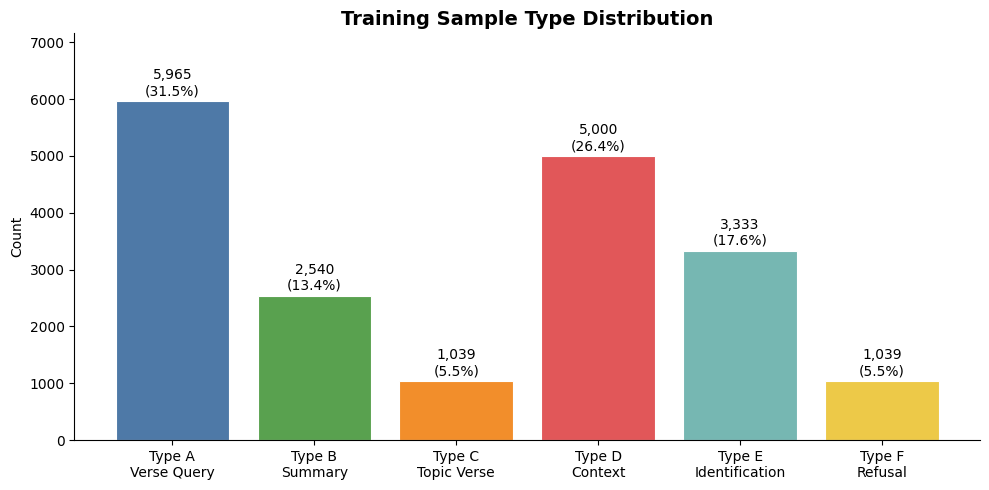


總樣本數: 18,916
Train: 17,024 | Test: 1,892


In [20]:
# ── 樣本類型分佈長條圖 ──

type_labels = {"A": "Verse Query", "B": "Summary", "C": "Topic Verse",
               "D": "Context", "E": "Identification", "F": "Refusal"}

# 統計 train + test
all_types = list(ds_dict["train"]["sample_type"]) + list(ds_dict["test"]["sample_type"])
type_counter = Counter(all_types)

types_sorted = sorted(type_counter.keys())
counts = [type_counter[t] for t in types_sorted]
labels = [f"Type {t}\n{type_labels.get(t, t)}" for t in types_sorted]
colors = ["#4e79a7", "#59a14f", "#f28e2b", "#e15759", "#76b7b2", "#edc948"]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(labels, counts, color=colors[:len(types_sorted)], edgecolor="white", linewidth=0.8)

for bar, count in zip(bars, counts):
    pct = count / sum(counts) * 100
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 50,
            f"{count:,}\n({pct:.1f}%)", ha="center", va="bottom", fontsize=10)

ax.set_title("Training Sample Type Distribution", fontsize=14, fontweight="bold")
ax.set_ylabel("Count")
ax.set_ylim(0, max(counts) * 1.2)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print(f"\n總樣本數: {sum(counts):,}")
print(f"Train: {len(ds_dict['train']):,} | Test: {len(ds_dict['test']):,}")

In [21]:
# ── 各類型樣本預覽 ──

def preview_samples(dataset, n_per_type: int = 1):
    """以 HTML 表格預覽各類型樣本。"""
    type_groups: dict[str, list] = {}
    for i, row in enumerate(dataset):
        st = row["sample_type"]
        type_groups.setdefault(st, []).append(row)

    html = "<style>td{vertical-align:top;padding:8px;border:1px solid #ddd;max-width:500px;word-wrap:break-word}</style>"
    html += "<table><tr><th>Type</th><th>問題 (User)</th><th>回答 (Assistant)</th></tr>"

    for st in sorted(type_groups):
        for row in type_groups[st][:n_per_type]:
            msgs = row["messages"]
            q = msgs[1]["content"]
            a = msgs[2]["content"]
            if len(a) > 300:
                a = a[:300] + "..."
            html += f"<tr><td><b>{st}</b><br>{type_labels.get(st, '')}</td>"
            html += f"<td>{q}</td><td>{a}</td></tr>"

    html += "</table>"
    display(HTML(html))

preview_samples(ds_dict["train"], n_per_type=2)

Type,問題 (User),回答 (Assistant)
AVerse Query,我想查利未記3章9節。,利未記3章9節寫道： 「從平安祭中，將火祭獻給耶和華，其中的脂油和整肥尾巴都要在靠近脊骨處取下，並要把蓋臟的脂油和臟上所有的脂油，」
AVerse Query,幫我查一下約拿書第1章第2節。,查閱約拿書第1章第2節，經文內容為： 「『你起來往尼尼微大城去，向其中的居民呼喊，因為他們的惡達到我面前。』」
BSummary,馬太福音第2章中「逃往埃及」這段經文在講什麼？,馬太福音第2章「逃往埃及」這段的內容如下： 第13節：他們去後，有主的使者向約瑟夢中顯現，說：「起來！帶着小孩子同他母親逃往埃及，住在那裏，等我吩咐你；因為希律必尋找小孩子，要除滅他。」 第14節：約瑟就起來，夜間帶着小孩子和他母親往埃及去， 第15節：住在那裏，直到希律死了。這是要應驗主藉先知所說的話，說：「我從埃及召出我的兒子來。」
BSummary,列王紀上第8章中「為民祝福」這個段落包含哪些經文？,列王紀上第8章「為民祝福」的段落經文如下所示： 第54節：所羅門在耶和華的壇前屈膝跪着，向天舉手，在耶和華面前禱告祈求已畢，就起來， 第55節：站着，大聲為以色列全會眾祝福，說： 第56節：「耶和華是應當稱頌的！因為他照着一切所應許的賜平安給他的民以色列人，凡藉他僕人摩西應許賜福的話，一句都沒有落空。」 第57節：願耶和華－我們的上帝與我們同在，像與我們列祖同在一樣，不撇下我們，不丟棄我們， 第58節：使我們的心歸向他，遵行他的道，謹守他吩咐我們列祖的誡命、律例、典章。 第59節：我在耶和華面前祈求的這些話，願耶和華－我們的上帝晝夜垂念，每日為他僕人與他民以色列伸冤， 第60節：使地上的萬民...
CTopic Verse,請列出聖經中提到「審判」的經文。,好的，以下是與「審判」相關的聖經經文： - 申命記第21章第2節：「長老和審判官就要出去，從被殺的人那裏量起，直量到四圍的城邑，」 - 詩篇第96章第13節：「因為他來了，他來要審判全地。 他要按公義審判世界， 按他的信實審判萬民。」 - 馬太福音第11章第24節：「『但我告訴你們，當審判的日子，所多瑪所受的，比你還容易受呢！』」 - 以賽亞書第24章第21節：「到那日，耶和華在高處必懲罰高處的眾軍，在地上必懲罰地上的列王。」 - 但以理書第9章第12節：「他使大災禍臨到我們，成就了警戒我們和審判我們官長的話；原來在普天之下未曾行過像在耶路撒冷所行的。」 - 以西結書第7章第3節：「現在你的...
CTopic Verse,「光明」這個主題在一般書信中有哪些相關經文？,一般書信中提到「光明」的經文如下： - 彼得前書第2章第9節：「惟有你們是被揀選的族類，是有君尊的祭司，是聖潔的國度，是屬上帝的子民，要叫你們宣揚那召你們出黑暗入奇妙光明者的美德。」 - 約翰一書第2章第10節：「愛弟兄的，就是住在光明中，在他並沒有絆跌的緣由。」 - 約翰一書第2章第9節：「人若說自己在光明中，卻恨他的弟兄，他到如今還是在黑暗裏。」 - 希伯來書第10章第32節：「你們要追念往日，蒙了光照以後所忍受大爭戰的各樣苦難：」 - 約翰一書第1章第7節：「我們若在光明中行，如同上帝在光明中，就彼此相交，他兒子耶穌的血也洗淨我們一切的罪。」 - 希伯來書第6章第4節：「論到那些已經蒙...
DContext,幫我看看加拉太書第3章第18節的前後文。,加拉太書3章18節出現在以下段落之中： 前文（第17節）：「我是這麼說，上帝預先所立的約，不能被那四百三十年以後的律法廢掉，叫應許歸於虛空。」 本節（第18節）：「因為承受產業，若本乎律法，就不本乎應許；但上帝是憑着應許把產業賜給亞伯拉罕。」 後文（第19節）：「這樣說來，律法是為甚麼有的呢？原是為過犯添上的，等候那蒙應許的子孫來到，並且是藉天使經中保之手設立的。」 這節經文位於「律法和應許」段落中。
DContext,請幫我查一下創世記第27章第7節的段落背景。,創世記第27章第7節的上下文如下： 前文（第6節）：「利百加就對她兒子雅各說：『我聽見你父親對你哥哥以掃說：』」 本節（第7節）：「『你去把野獸帶來，做成美味給我吃，我好在未死之先，在耶和華面前給你祝福。』」 後文（第8節）：「現在，我兒，你要照着我所吩咐你的，聽從我的話。」 這節經文位於「以撒祝福雅各」段落中。
EIdentification,請幫我找一下「亞基帕王啊，猶太人所告我的一切事，今日得在你面前分訴，實為萬幸；」這段經文的出處。,沒錯，「亞基帕王啊，猶太人所告我的一切事，今日得在你面前分訴，實為萬幸；」的確出自使徒行傳第26章第2節，位於「保羅在亞基帕王面前申辯」段落。
EIdentification,請幫我找一下「如今我勸你們將他們的田地、葡萄園、橄欖園、房屋，並向他們所取的銀錢、糧食、新酒，和油，百分之一的利息都歸還他們。」這段經文的出處。,這段經文的出處是尼西米記第5章第11節。


/tmp/ipykernel_55/4016960194.py:18: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True,


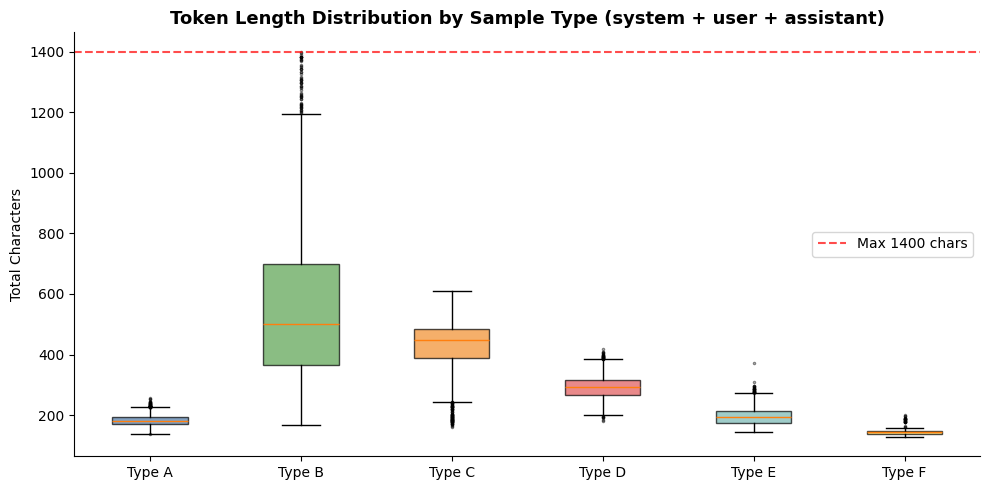

  Type A: mean=183, median=182, max=257
  Type B: mean=559, median=502, max=1400
  Type C: mean=420, median=447, max=609
  Type D: mean=292, median=292, max=420
  Type E: mean=197, median=194, max=372
  Type F: mean=144, median=143, max=199


In [22]:
# ── 文字長度分析箱型圖 ──

def compute_lengths(dataset) -> dict[str, list[int]]:
    """計算各類型樣本的總字元數。"""
    lengths: dict[str, list[int]] = {}
    for row in dataset:
        st = row["sample_type"]
        total = sum(len(m["content"]) for m in row["messages"])
        lengths.setdefault(st, []).append(total)
    return lengths

lengths = compute_lengths(ds_dict["train"])
types_sorted = sorted(lengths.keys())
data = [lengths[t] for t in types_sorted]
labels = [f"Type {t}" for t in types_sorted]

fig, ax = plt.subplots(figsize=(10, 5))
bp = ax.boxplot(data, labels=labels, patch_artist=True, showfliers=True,
                flierprops={"marker": ".", "markersize": 3, "alpha": 0.5})
for patch, color in zip(bp["boxes"], colors[:len(types_sorted)]):
    patch.set_facecolor(color)
    patch.set_alpha(0.7)

ax.axhline(y=_MAX_TOTAL_CHARS, color="red", linestyle="--", alpha=0.7, label=f"Max {_MAX_TOTAL_CHARS} chars")
ax.set_title("Token Length Distribution by Sample Type (system + user + assistant)", fontsize=13, fontweight="bold")
ax.set_ylabel("Total Characters")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

for t in types_sorted:
    vals = lengths[t]
    print(f"  Type {t}: mean={sum(vals)/len(vals):.0f}, median={sorted(vals)[len(vals)//2]}, max={max(vals)}")

---
## Section 8: QLoRA 微調訓練

### QLoRA 原理

QLoRA（Quantized LoRA）結合 4-bit 量化與 LoRA adapter：
1. **4-bit NF4 量化** — 將 base model 權重壓縮至 4-bit，大幅降低 VRAM 需求
2. **LoRA adapter** — 僅訓練低秩分解矩陣（r=32），參數量極少
3. **Double quantization** — 進一步壓縮量化常數

### 超參數

| 參數 | 值 | 說明 |
|------|-----|------|
| LoRA r | 32 | 低秩矩陣的秩 |
| LoRA alpha | 64 | 縮放係數 (alpha/r = 2) |
| Batch size | 2 | 每 GPU batch size |
| Grad accum | 8 | 等效 batch = 16 |
| Learning rate | 1e-4 | cosine scheduler |
| Epochs | 2 | 訓練輪數 |
| Max length | 2560 | 最大 token 長度 |
| Packing | True | 多樣本打包加速訓練 |

### VRAM 估算

- 12B 模型 4-bit: ~7GB
- LoRA adapter + optimizer: ~3GB
- Activations (grad checkpoint): ~3-5GB
- **總計: ~13-15GB** (建議 16GB+)

In [23]:
# ── 載入模型 + Tokenizer + 量化設定 ──
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig
from peft import LoraConfig
from trl import SFTConfig, SFTTrainer

# 載入 dataset（如果從 checkpoint 重新開始）
from datasets import load_from_disk
dataset_path = os.path.join(OUTPUT_DIR, "bible_dataset")
if "ds_dict" not in dir() or ds_dict is None:
    print("從 checkpoint 載入 Dataset...")
    ds_dict = load_from_disk(dataset_path)

# 量化設定
quant_cfg = CONFIG["quantization"]
compute_dtype = getattr(torch, quant_cfg["bnb_4bit_compute_dtype"])
bnb_config = BitsAndBytesConfig(
    load_in_4bit=quant_cfg["load_in_4bit"],
    bnb_4bit_quant_type=quant_cfg["bnb_4bit_quant_type"],
    bnb_4bit_use_double_quant=quant_cfg["bnb_4bit_use_double_quant"],
    bnb_4bit_compute_dtype=compute_dtype,
)

# Tokenizer
print("載入 tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(MODEL_ID, token=HF_TOKEN)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# Gemma 3 tokenizer 會包含 token_type_ids，但 SFTTrainer 不會產生它，需移除
if "token_type_ids" in tokenizer.model_input_names:
    tokenizer.model_input_names.remove("token_type_ids")

# Model
print("載入模型（4-bit 量化）...")
model = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
    torch_dtype=torch.bfloat16,
    token=HF_TOKEN,
)

gpu_mem()
print(f"Total parameters: {model.num_parameters():,}")
if hasattr(model, "hf_device_map"):
    print(f"Device map: {dict(Counter(model.hf_device_map.values()))}")

載入 tokenizer...


config.json:   0%|          | 0.00/855 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json:   0%|          | 0.00/33.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/35.0 [00:00<?, ?B/s]

...

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/215 [00:00<?, ?B/s]

  GPU[0]: 3.02 / 15.9 GB (reserved: 7.52 GB)
Total parameters: 4,300,079,472


In [24]:
# ── LoRA + SFT 設定 ──
lora_cfg = CONFIG["lora"]
lora_config = LoraConfig(
    r=lora_cfg["r"],
    lora_alpha=lora_cfg["lora_alpha"],
    lora_dropout=lora_cfg["lora_dropout"],
    target_modules=lora_cfg["target_modules"],
    bias=lora_cfg["bias"],
    task_type=lora_cfg["task_type"],
)

train_cfg = CONFIG["training"]
sft_kwargs = {
    "output_dir": train_cfg["output_dir"],
    "num_train_epochs": train_cfg["num_train_epochs"],
    "per_device_train_batch_size": train_cfg["per_device_train_batch_size"],
    "gradient_accumulation_steps": train_cfg["gradient_accumulation_steps"],
    "learning_rate": train_cfg["learning_rate"],
    "weight_decay": train_cfg["weight_decay"],
    "max_length": train_cfg["max_length"],
    "packing": train_cfg["packing"],
    "gradient_checkpointing": train_cfg["gradient_checkpointing"],
    "optim": train_cfg["optim"],
    "lr_scheduler_type": train_cfg["lr_scheduler_type"],
    "warmup_ratio": train_cfg["warmup_ratio"],
    "logging_steps": train_cfg["logging_steps"],
    "save_strategy": train_cfg["save_strategy"],
    "save_steps": train_cfg["save_steps"],
    "save_total_limit": train_cfg["save_total_limit"],
    "eval_strategy": train_cfg["eval_strategy"],
    "eval_steps": train_cfg["eval_steps"],
    "bf16": train_cfg["bf16"],
    "report_to": train_cfg["report_to"],
}
# Multi-GPU: disable unused param detection for model-parallel QLoRA
if torch.cuda.device_count() > 1:
    sft_kwargs["ddp_find_unused_parameters"] = False

if train_cfg.get("neftune_noise_alpha") is not None:
    sft_kwargs["neftune_noise_alpha"] = train_cfg["neftune_noise_alpha"]
if train_cfg.get("load_best_model_at_end"):
    sft_kwargs["load_best_model_at_end"] = True
    sft_kwargs["metric_for_best_model"] = train_cfg.get("metric_for_best_model", "eval_loss")

sft_config = SFTConfig(**sft_kwargs)

# 如需 Trackio 追蹤，取消以下註解：
# import trackio
# trackio.init(
#     project="bible-fine-tuning",
#     name="qlora-google/gemma-3-4b-it",
#     space_id="KenZx0521/fine-tuning_bible",
#     config={...},
# )

trainer = SFTTrainer(
    model=model,
    args=sft_config,
    train_dataset=ds_dict["train"],
    eval_dataset=ds_dict["test"],
    peft_config=lora_config,
    processing_class=tokenizer,
)

# Gemma 3 訓練時強制要求 token_type_ids，但 SFTTrainer 不會產生它
# 包裝 data collator，自動注入 token_type_ids（全 0 = 純文字）
_original_collator = trainer.data_collator

def _collator_with_token_type_ids(features, **kwargs):
    batch = _original_collator(features, **kwargs)
    if "token_type_ids" not in batch:
        batch["token_type_ids"] = torch.zeros_like(batch["input_ids"])
    return batch

trainer.data_collator = _collator_with_token_type_ids

print(f"Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
print(f"Total parameters: {model.num_parameters():,}")
gpu_mem()

warmup_ratio is deprecated and will be removed in v5.2. Use `warmup_steps` instead.
Padding-free training is enabled, but the attention implementation is not set to a supported flash attention variant. Padding-free training flattens batches into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, kernels-community/flash-attn2, kernels-community/flash-attn3, kernels-community/vllm-flash-attn3. Using other implementations may lead to unexpected behavior. To ensure compatibility, set `attn_implementation` in the model configuration to one of these supported options or verify that your attention mechanism can handle flattened sequences.
You are using packing, but the attention implementation is not set to a supported flash attention variant. Packing gathers multiple samples into a single sequence, and only the following implementations are known to reliably support this: flash_attention_2, flash_attention_3, ke

Tokenizing train dataset:   0%|          | 0/17024 [00:00<?, ? examples/s]

Packing train dataset:   0%|          | 0/17024 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/1892 [00:00<?, ? examples/s]

Packing eval dataset:   0%|          | 0/1892 [00:00<?, ? examples/s]

Trainable parameters: 38,497,792
Total parameters: 4,338,577,264
  GPU[0]: 3.09 / 15.9 GB (reserved: 7.66 GB)


In [ ]:
%%time
# ── 執行訓練 ──
print("開始訓練...")
trainer.train()

# 儲存 adapter
adapter_path = os.path.join(train_cfg["output_dir"], "final_adapter")
trainer.save_model(adapter_path)
tokenizer.save_pretrained(adapter_path)
print(f"\nLoRA adapter 已儲存至: {adapter_path}")

# trackio.finish()  # 如有啟用 Trackio，取消此行註解

gpu_mem()

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1, 'bos_token_id': 2, 'pad_token_id': 0}.


開始訓練...


Step,Training Loss,Validation Loss


In [ ]:
# ── 訓練曲線視覺化 ──

log_history = trainer.state.log_history

# 擷取 loss 與 eval_loss
train_steps, train_losses = [], []
eval_steps_list, eval_losses = [], []

for entry in log_history:
    if "loss" in entry and "eval_loss" not in entry:
        train_steps.append(entry.get("step", 0))
        train_losses.append(entry["loss"])
    if "eval_loss" in entry:
        eval_steps_list.append(entry.get("step", 0))
        eval_losses.append(entry["eval_loss"])

fig, ax = plt.subplots(figsize=(10, 5))
if train_steps:
    ax.plot(train_steps, train_losses, label="Train Loss", alpha=0.7, linewidth=1)
if eval_steps_list:
    ax.plot(eval_steps_list, eval_losses, label="Eval Loss", marker="o", markersize=4, linewidth=2)

ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.set_title("Training & Validation Loss", fontsize=14, fontweight="bold")
ax.legend()
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

if eval_losses:
    print(f"Best Eval Loss: {min(eval_losses):.4f} (step {eval_steps_list[eval_losses.index(min(eval_losses))]})")

---
## Section 9: GPU 清理與模型合併

### 流程

1. **釋放訓練資源** — 刪除 model、trainer 物件並清空 GPU cache
2. **合併 LoRA adapter** — 將 adapter 權重合併至 base model，產生獨立可部署的完整模型

合併後的模型可以直接用於推論，不需要 PEFT 庫。

In [ ]:
# ── GPU 清理 ──
print("釋放訓練資源...")
if "trainer" in dir():
    del trainer
if "model" in dir():
    del model
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()
gpu_mem()
print("GPU 記憶體已釋放")

In [ ]:
# ── 合併 LoRA adapter 到 base model ──
from peft import PeftModel

adapter_dir = os.path.join(CONFIG["training"]["output_dir"], "final_adapter")
merged_dir = os.path.join(OUTPUT_DIR, "merged_model")

if not os.path.exists(adapter_dir):
    print(f"[警告] Adapter 路徑不存在: {adapter_dir}")
    print("請先執行 Section 8 的訓練步驟。")
else:
    print("=" * 60)
    print("Merge LoRA Adapter")
    print("=" * 60)

    # 載入 tokenizer
    print("\n[1/4] 載入 tokenizer...")
    merge_tokenizer = AutoTokenizer.from_pretrained(adapter_dir)

    # 載入 base model (bf16)
    print("\n[2/4] 載入 base model (bf16)...")
    base_model = AutoModelForCausalLM.from_pretrained(
        MODEL_ID,
        torch_dtype=torch.bfloat16,
        device_map="auto",
        token=HF_TOKEN,
    )
    gpu_mem()

    # 合併 LoRA
    print("\n[3/4] 合併 LoRA adapter...")
    peft_model = PeftModel.from_pretrained(base_model, adapter_dir)
    merged_model = peft_model.merge_and_unload()

    # 儲存
    print("\n[4/4] 儲存合併模型...")
    os.makedirs(merged_dir, exist_ok=True)
    merged_model.save_pretrained(merged_dir)
    merge_tokenizer.save_pretrained(merged_dir)
    print(f"  已儲存至: {merged_dir}")

    # 清理
    del base_model, peft_model, merged_model, merge_tokenizer
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print("\n合併完成！")
    gpu_mem()

---
## Section 10: 多維度評估

### 評估維度

| 維度 | 指標 | 說明 |
|------|------|------|
| 經文召回 | ROUGE-L + Exact Match | 查詢經文時的回覆準確度 |
| 經文辨識 | Accuracy | 從片段反查書卷/章/節的正確率 |
| 抗幻覺 | Hallucination Rate | 面對不存在的經文時的拒絕率 |

In [ ]:
# ── 載入模型 + 生成函式 ──
from rouge_score import rouge_scorer

def _load_eval_model(model_path: str | None = None):
    """載入模型用於評估（優先嘗試 PEFT，降級為完整模型）。"""
    if model_path:
        path = model_path
    elif os.path.exists(os.path.join(OUTPUT_DIR, "merged_model")):
        path = os.path.join(OUTPUT_DIR, "merged_model")
    elif os.path.exists(os.path.join(OUTPUT_DIR, "bible-assistant", "final_adapter")):
        path = os.path.join(OUTPUT_DIR, "bible-assistant", "final_adapter")
    else:
        raise FileNotFoundError("找不到模型。請先執行訓練步驟。")

    print(f"載入模型: {path}")
    eval_tokenizer = AutoTokenizer.from_pretrained(path)
    if eval_tokenizer.pad_token is None:
        eval_tokenizer.pad_token = eval_tokenizer.eos_token

    try:
        from peft import PeftModel as PM
        base = AutoModelForCausalLM.from_pretrained(
            MODEL_ID, torch_dtype=torch.bfloat16, device_map="auto", token=HF_TOKEN,
        )
        eval_model = PM.from_pretrained(base, path)
        print("  (LoRA adapter 模式)")
    except (ImportError, ValueError, OSError):
        eval_model = AutoModelForCausalLM.from_pretrained(
            path, torch_dtype=torch.bfloat16, device_map="auto",
        )
        print("  (完整模型模式)")

    eval_model.eval()
    return eval_model, eval_tokenizer


def _generate_response(model, tokenizer, question: str, max_new_tokens: int = 512) -> str:
    """生成模型回應。"""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs, max_new_tokens=max_new_tokens, do_sample=False, temperature=1.0,
        )
    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )
    return response.strip()


eval_model, eval_tokenizer = _load_eval_model()
gpu_mem()

In [ ]:
# ── 三個評估函式 ──

def evaluate_verse_recall(model, tokenizer, books, n_samples: int = 500, seed: int = 42) -> dict:
    """經文召回: ROUGE-L + Exact Match。"""
    rng = random.Random(seed)
    all_verses = [v for b in books for c in b.chapters for s in c.sections for v in s.verses]
    selected = rng.sample(all_verses, min(n_samples, len(all_verses)))

    scorer = rouge_scorer.RougeScorer(["rougeL"], use_stemmer=False)
    rouge_scores = []
    exact_matches = 0

    for verse in tqdm(selected, desc="經文召回"):
        question = f"{verse.book}第{verse.chapter}章第{verse.verse_number}節的經文是什麼？"
        response = _generate_response(model, tokenizer, question)
        score = scorer.score(verse.text, response)
        rouge_scores.append(score["rougeL"].fmeasure)
        if verse.text in response:
            exact_matches += 1

    avg_rouge = sum(rouge_scores) / len(rouge_scores) if rouge_scores else 0
    return {
        "avg_rouge_l": round(avg_rouge, 4),
        "exact_match_rate": round(exact_matches / len(selected), 4),
        "n_samples": len(selected),
    }


def evaluate_verse_identification(model, tokenizer, books, n_samples: int = 200, seed: int = 42) -> dict:
    """經文辨識: 從片段反查出處。"""
    rng = random.Random(seed)
    all_verses = [
        v for b in books for c in b.chapters for s in c.sections
        for v in s.verses if len(v.text) >= 15
    ]
    selected = rng.sample(all_verses, min(n_samples, len(all_verses)))

    correct = 0
    for verse in tqdm(selected, desc="經文辨識"):
        snippet = verse.text[:50] if len(verse.text) > 50 else verse.text
        question = f"「{snippet}」這句經文出自聖經哪裏？"
        response = _generate_response(model, tokenizer, question, max_new_tokens=128)
        if verse.book in response and str(verse.chapter) in response:
            correct += 1

    return {
        "accuracy": round(correct / len(selected), 4),
        "n_samples": len(selected),
    }


def evaluate_anti_hallucination(model, tokenizer, n_samples: int = 50) -> dict:
    """抗幻覺: 面對不存在的經文時的拒絕率。"""
    fake_questions = [
        "請引用創世記第100章第1節的經文。",
        "啟示錄第50章第10節說了什麼？",
        "馬太福音第99章第5節的經文是什麼？",
        "希伯來書第30章第1節的內容為何？",
        "以賽亞書第200章第3節的經文是什麼？",
    ]
    fake_books = ["保羅書", "彼拉多書", "馬利亞福音", "多馬福音", "巴拿巴書"]
    for book in fake_books:
        for ch in [1, 5, 10]:
            fake_questions.append(f"{book}第{ch}章第1節的經文是什麼？")

    rng = random.Random(42)
    selected = rng.sample(fake_questions, min(n_samples, len(fake_questions)))

    hallucinations = 0
    refusal_keywords = ["不存在", "沒有", "找不到", "並非", "無法", "超出", "沒有這", "不確定"]

    for question in tqdm(selected, desc="抗幻覺"):
        response = _generate_response(model, tokenizer, question, max_new_tokens=256)
        if not any(kw in response for kw in refusal_keywords):
            hallucinations += 1

    return {
        "hallucination_rate": round(hallucinations / len(selected), 4),
        "n_samples": len(selected),
    }

In [ ]:
%%time
# ── 執行評估 ──

# 解析聖經（如果 books 不在記憶體中）
if "books" not in dir():
    books = parse_all_books(DATA_DIR)

results = {}

print("\n[1/3] 經文召回評估...")
results["verse_recall"] = evaluate_verse_recall(eval_model, eval_tokenizer, books)
print(f"  ROUGE-L: {results['verse_recall']['avg_rouge_l']}")
print(f"  Exact Match: {results['verse_recall']['exact_match_rate']}")

print("\n[2/3] 經文辨識評估...")
results["verse_identification"] = evaluate_verse_identification(eval_model, eval_tokenizer, books)
print(f"  Accuracy: {results['verse_identification']['accuracy']}")

print("\n[3/3] 抗幻覺評估...")
results["anti_hallucination"] = evaluate_anti_hallucination(eval_model, eval_tokenizer)
print(f"  Hallucination Rate: {results['anti_hallucination']['hallucination_rate']}")

# 儲存結果
results_path = os.path.join(OUTPUT_DIR, "evaluation_results.json")
os.makedirs(OUTPUT_DIR, exist_ok=True)
with open(results_path, "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)
print(f"\n結果已儲存至: {results_path}")

In [ ]:
# ── 評估結果視覺化 ──

metrics = {
    "ROUGE-L": results["verse_recall"]["avg_rouge_l"],
    "Exact Match": results["verse_recall"]["exact_match_rate"],
    "Identification\nAccuracy": results["verse_identification"]["accuracy"],
    "Refusal Rate\n(1-Hallucination)": 1 - results["anti_hallucination"]["hallucination_rate"],
}

fig, ax = plt.subplots(figsize=(8, 5))
bars = ax.bar(metrics.keys(), metrics.values(),
              color=["#4e79a7", "#59a14f", "#f28e2b", "#76b7b2"],
              edgecolor="white", linewidth=0.8)

for bar, val in zip(bars, metrics.values()):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{val:.2%}", ha="center", va="bottom", fontsize=12, fontweight="bold")

ax.set_ylim(0, 1.15)
ax.set_ylabel("Score")
ax.set_title("Model Evaluation Results", fontsize=14, fontweight="bold")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
plt.tight_layout()
plt.show()

print("\nEvaluation Summary:")
print(f"  Verse Recall ROUGE-L:     {results['verse_recall']['avg_rouge_l']:.4f}")
print(f"  Verse Recall Exact Match: {results['verse_recall']['exact_match_rate']:.4f}")
print(f"  Identification Accuracy:  {results['verse_identification']['accuracy']:.4f}")
print(f"  Hallucination Rate:       {results['anti_hallucination']['hallucination_rate']:.4f}")

---
## Section 11: 互動推論

載入微調後的模型，透過互動介面進行即時問答測試。

### 範例問題

- `創世記第1章第1節的經文是什麼？`
- `請列出聖經中關於「信心」的經文。`
- `「太初有道」這句經文出自哪裏？`
- `馬太福音第5章第3節的上下文是什麼？`
- `保羅書第1章第1節的經文是什麼？`（拒絕測試）

In [ ]:
# ── 推論函式 ──

def generate(
    model, tokenizer, question: str, *,
    temperature: float = 0.7, top_p: float = 0.9, max_new_tokens: int = 512,
) -> str:
    """生成回應（支援取樣參數調整）。"""
    messages = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": question},
    ]
    input_text = tokenizer.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    inputs = tokenizer(input_text, return_tensors="pt").to(model.device)
    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=max_new_tokens,
            do_sample=temperature > 0,
            temperature=temperature if temperature > 0 else 1.0,
            top_p=top_p,
        )
    response = tokenizer.decode(
        outputs[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True
    )
    return response.strip()

# 載入模型（如果尚未載入）
if "eval_model" not in dir():
    eval_model, eval_tokenizer = _load_eval_model()

# 測試推論
test_q = "創世記第1章第1節的經文是什麼？"
print(f"Q: {test_q}")
print(f"A: {generate(eval_model, eval_tokenizer, test_q)}")

In [ ]:
# ── 互動推論（在 Notebook 中使用 input loop）──

print("=" * 60)
print("聖經知識助手 — 互動模式")
print("=" * 60)
print("輸入問題開始對話，輸入 'quit' 或 'exit' 退出")
print("-" * 60)

while True:
    try:
        user_input = input("\n你: ").strip()
    except (EOFError, KeyboardInterrupt):
        print("\n再見！")
        break

    if not user_input:
        continue
    if user_input.lower() in ("quit", "exit"):
        print("再見！")
        break

    response = generate(eval_model, eval_tokenizer, user_input)
    print(f"\n助手: {response}")

---
## Section 12: 清理與總結

### 完成項目

- [x] 解析 66 卷聖經 Markdown 檔案
- [x] 生成 ~19,000 筆訓練樣本（6 種類型）
- [x] QLoRA 微調 google/gemma-3-4b-it 模型
- [x] 合併 LoRA adapter
- [x] 多維度評估
- [x] 互動推論測試

### 產出檔案

| 路徑 | 說明 |
|------|------|
| `outputs/bible_dataset/` | HuggingFace Dataset（train + test） |
| `outputs/bible-assistant/final_adapter/` | LoRA adapter 權重 |
| `outputs/merged_model/` | 合併後的完整模型 |
| `outputs/evaluation_results.json` | 評估結果 |

### 後續步驟

1. **部署**: 將合併模型上傳至 Hugging Face Hub
2. **API 化**: 使用 vLLM / TGI 建立推論 API
3. **持續改進**: 根據評估結果調整訓練資料或超參數

In [ ]:
# ── 釋放所有 GPU 資源 ──
for var_name in ["eval_model", "eval_tokenizer", "model", "trainer"]:
    if var_name in dir():
        exec(f"del {var_name}")

gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()
    torch.cuda.synchronize()

gpu_mem()
print("\n所有資源已釋放。Notebook 執行完畢！")